In [15]:
import src.util as util
import importlib
importlib.reload(util)

import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import numpy as np

from scipy import stats
import seaborn as sns
from adjustText import adjust_text

matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams['font.family'] = 'Helvetica' 

## Road DDO and reddit datasets

In [8]:
data_path = './data/llm-inference-data/'
data_ddo = pd.read_parquet(data_path + 'df_ddo_hf.parquet')
data_reddit = pd.read_parquet(data_path + 'df_reddit_hf.parquet')

In [9]:
data_ddo.columns

Index(['user_name', 'debate_title', 'debate_texts', 'party', 'party_short',
       'debate_category', 'context', 'num_token', 'short_text',
       'num_token_short', 'party_out_gpt4o', 'confidence_gpt4o',
       'party_out_llama8b', 'confidence_llama8b', 'clean_text',
       'title_embedding', 'context_embedding'],
      dtype='object')

In [10]:
data_reddit.head(2)

,user_name,party_short,subreddit,comment_body,num_tokens,inferred_category,party_out_gpt4o,confidence_gpt4o,party_out_llama8b,confidence_llama8b,clean_text,context_embedding
0,-BrutusBuckeye,Republican,AskAChristian,I believe you're thinking of the NAB Do not be...,314,Religion,Republican,4.0,Republican,1.0,believe thinking nab surprised brothers sister...,"[0.02592448, -0.00443687, 0.021642983, 0.00439..."
1,-BrutusBuckeye,Republican,CFB,"What do you mean? Gus ""Jaguar"" Johnson is my d...",701,Sports,Democratic,1.0,Republican,2.0,mean gus jaguar johnson dude im fine hot take ...,"[0.031178573, 0.07059129, 0.022134107, -0.0191..."


## Relation between confidence and inference accruacy 

In [3]:
#f1-scores
f1_conf_list_ddo_gpt, f1_ddo_gpt, f1_errors_ddo_gpt = util.get_f1_over_conf(data_ddo, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

f1_conf_list_ddo_llama, f1_ddo_llama, f1_errors_ddo_llama = util.get_f1_over_conf(data_ddo, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

f1_conf_list_reddit_gpt, f1_reddit_gpt, f1_errors_reddit_gpt = util.get_f1_over_conf(data_reddit, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

f1_conf_list_reddit_llama, f1_reddit_llama, f1_errors_reddit_llama = util.get_f1_over_conf(data_reddit, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

### Figure 1b, c (confidence vs. F1 score of the text-level inference )

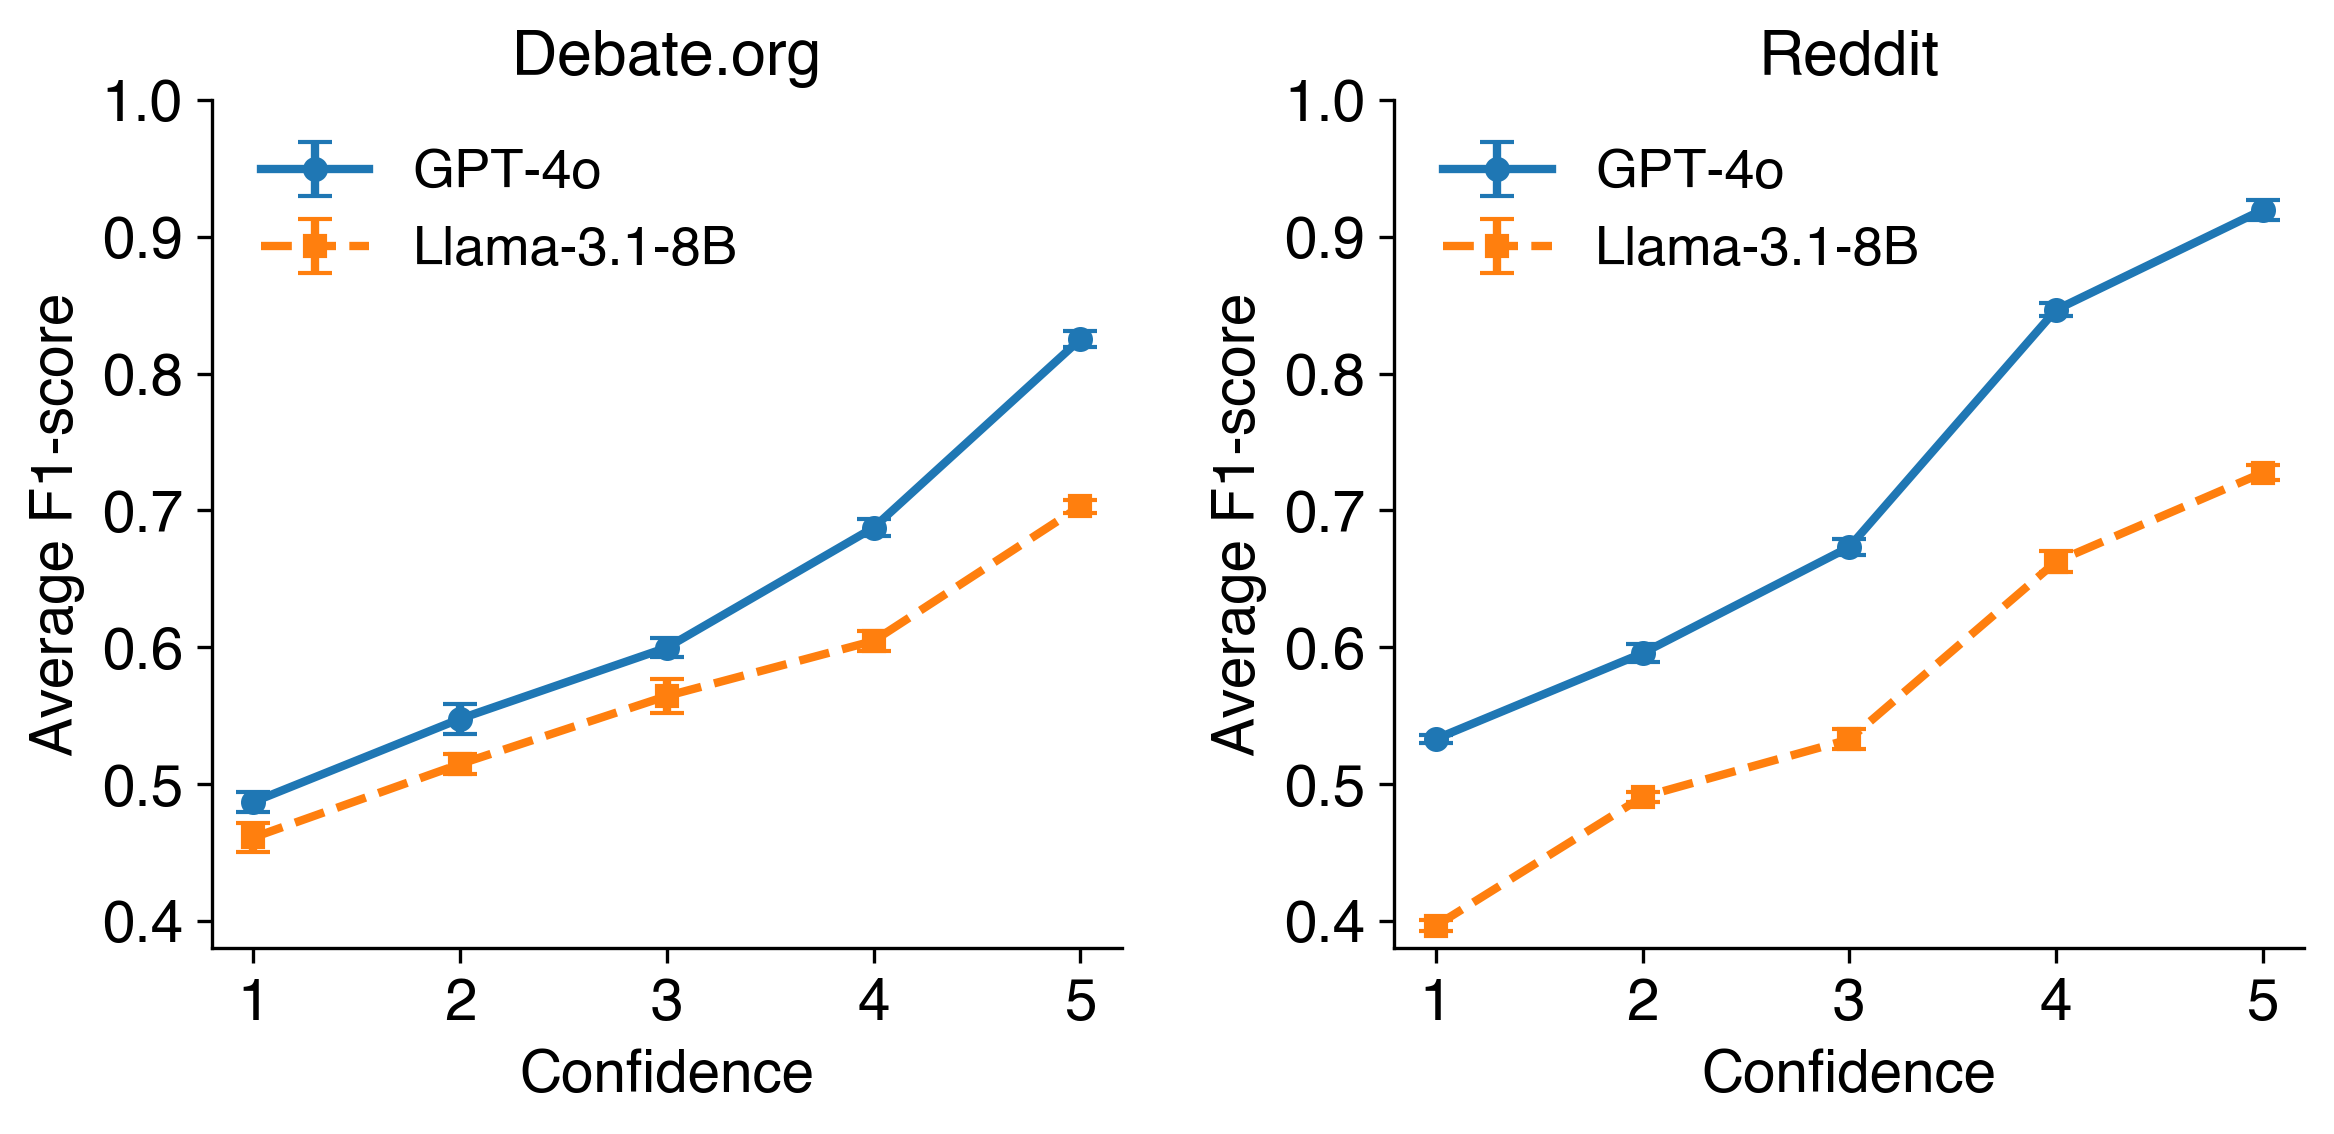

In [8]:
# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Adjust fonts for readability
plt.rc('font', size=14)  # default text size
plt.rc('axes', titlesize=15, labelsize=14)  # title and axis label sizes

# Plot for Debate.org
axes[0].errorbar(f1_conf_list_ddo_gpt, f1_ddo_gpt, yerr=f1_errors_ddo_gpt, label='GPT-4o', 
                 fmt='o-', linewidth=2, markersize=5, capsize=4)
axes[0].errorbar(f1_conf_list_ddo_llama, f1_ddo_llama, yerr=f1_errors_ddo_llama, label='Llama-3.1-8B',
                 fmt='s--', linewidth=2, markersize=5, capsize=4)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_title('Debate.org')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Average F1-score')
axes[0].legend(frameon=False, loc=2, fontsize=13)
#axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot for Reddit
axes[1].errorbar(f1_conf_list_reddit_gpt, f1_reddit_gpt, yerr=f1_errors_reddit_gpt, label='GPT-4o', 
                 fmt='o-', linewidth=2, markersize=5, capsize=4)
axes[1].errorbar(f1_conf_list_reddit_llama, f1_reddit_llama, yerr=f1_errors_reddit_llama, label='Llama-3.1-8B', 
                 fmt='s--', linewidth=2, markersize=5, capsize=4)
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_title('Reddit')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Average F1-score')
axes[1].legend(frameon=False, loc=2, fontsize=13)
#axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Clean up the plot (remove top/right spines)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0.38, 1)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
# Show the plot
plt.show()


### Figure 1 d, e (Distributions of confidence)

In [3]:
conf_dist_ddo_gpt = util.get_conf_distribution(data_ddo, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

conf_dist_ddo_llama = util.get_conf_distribution(data_ddo, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

conf_dist_reddit_gpt = util.get_conf_distribution(data_reddit, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

conf_dist_reddit_llama = util.get_conf_distribution(data_reddit, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

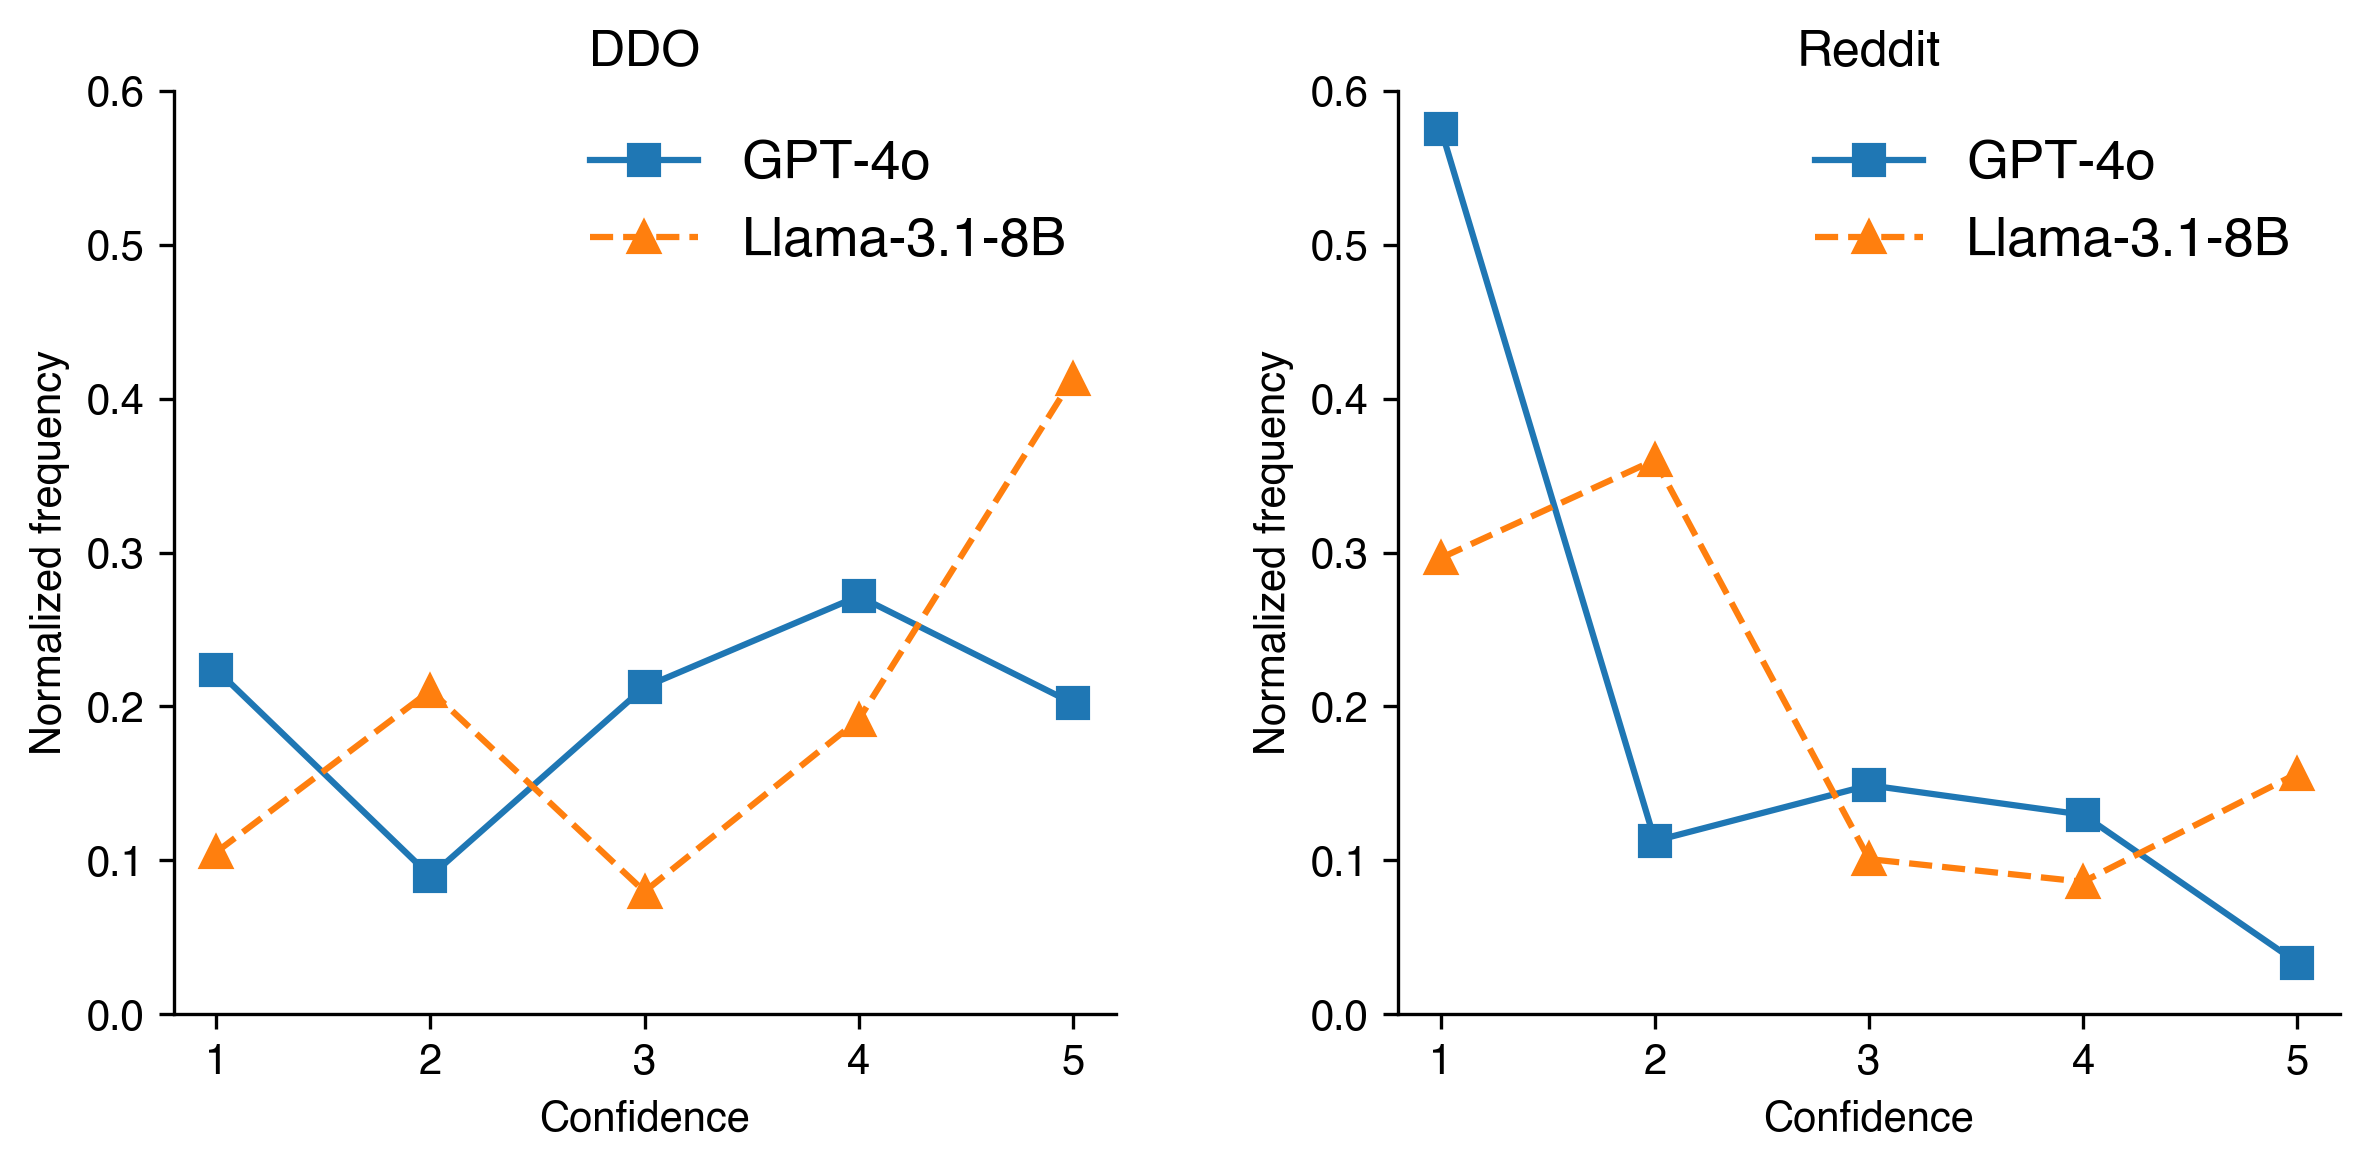

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

axes[0].plot(np.arange(1,6), conf_dist_ddo_gpt, 's-',  ms=7, label='GPT-4o')
axes[0].plot(np.arange(1,6), conf_dist_ddo_llama, '^--',  ms=7, label='Llama-3.1-8B')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0,0.6)
axes[0].set_title("DDO")
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Normalized frequency')
axes[0].legend(frameon=False, fontsize=13)


axes[1].plot(np.arange(1,6), conf_dist_reddit_gpt,   's-', ms=7 , label='GPT-4o')
axes[1].plot(np.arange(1,6), conf_dist_reddit_llama, '^--', ms=7 , label='Llama-3.1-8B')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_ylim(0,0.6)
axes[1].set_title("Reddit")
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Normalized frequency')
axes[1].legend(frameon=False, fontsize=13)

# Clean up the plot (remove top/right spines)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
# Show the plot
plt.show()

## Calculate text- and user-level inference and compute F1 scores

In [6]:
#example : calculation of text-level, user-level(majority, conf-weighted, max-conf) F1 scores
util.user_level_f1_fourtypes(data_ddo, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')

(0.6465938459097378,
 0.7033612627650411,
 0.7257321380640238,
 0.7237062062741881)

### 1. DDO - GPT-4o

F1 scores based on the inference results of GPT-4o (for Aggregated, Political, and General cases)

In [7]:
def print_three_decimals(values: tuple[float, ...]) -> None:
    formatted = tuple(f"{v:.3f}" for v in values)
    print(formatted)

In [8]:
print("1. Aggregated")
result_ddo_gpt4  = util.user_level_f1_fourtypes(data_ddo, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_ddo_gpt4)

print("2. Political")
data_ddo_pol    = data_ddo[data_ddo['debate_category']=='Politics']
result_ddo_pol_gpt4 = util.user_level_f1_fourtypes(data_ddo_pol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_ddo_pol_gpt4)

print("3. General")
data_ddo_nonpol = data_ddo[data_ddo['debate_category']!='Politics']
result_ddo_nonpol_gpt4 = util.user_level_f1_fourtypes(data_ddo_nonpol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_ddo_nonpol_gpt4)

1. Aggregated
('0.647', '0.703', '0.726', '0.724')
2. Political
('0.711', '0.740', '0.754', '0.750')
3. General
('0.619', '0.661', '0.682', '0.685')


### 2. DDO - Llama-3.1-8B

In [9]:
print("1. Aggregated")
result_ddo_llama8b  = util.user_level_f1_fourtypes(data_ddo, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_ddo_llama8b)

print("2. Political")
data_ddo_pol    = data_ddo[data_ddo['debate_category']=='Politics']
result_ddo_pol_llama8b = util.user_level_f1_fourtypes(data_ddo_pol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_ddo_pol_llama8b)

print("3. General")
data_ddo_nonpol = data_ddo[data_ddo['debate_category']!='Politics']
result_ddo_nonpol_llama8b = util.user_level_f1_fourtypes(data_ddo_nonpol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_ddo_nonpol_llama8b)

1. Aggregated
('0.619', '0.666', '0.682', '0.695')
2. Political
('0.681', '0.716', '0.725', '0.728')
3. General
('0.595', '0.628', '0.641', '0.647')


### 3. Reddit - GPT-4o

In [10]:
print("1. Aggregated")
result_reddit_gpt4  = util.user_level_f1_fourtypes(data_reddit, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_reddit_gpt4)

print("2. Political")
data_reddit_pol    = data_reddit[data_reddit['inferred_category']=='Politics']
result_reddit_pol_gpt4 = util.user_level_f1_fourtypes(data_reddit_pol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_reddit_pol_gpt4)

print("3. General")
data_reddit_nonpol = data_reddit[data_reddit['inferred_category']!='Politics']
result_reddit_nonpol_gpt4 = util.user_level_f1_fourtypes(data_reddit_nonpol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_reddit_nonpol_gpt4)

1. Aggregated
('0.624', '0.727', '0.817', '0.839')
2. Political
('0.777', '0.805', '0.821', '0.829')
3. General
('0.606', '0.683', '0.772', '0.799')


### Reddit - Llama-3.1-8B

In [11]:
print("1. Aggregated")
result_reddit_llama8b  = util.user_level_f1_fourtypes(data_reddit, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_reddit_llama8b)

print("2. Political")
data_reddit_pol    = data_reddit[data_reddit['inferred_category']=='Politics']
result_reddit_pol_llama8b = util.user_level_f1_fourtypes(data_reddit_pol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_reddit_pol_llama8b)

print("3. General")
data_reddit_nonpol = data_reddit[data_reddit['inferred_category']!='Politics']
result_reddit_nonpol_llama8b = util.user_level_f1_fourtypes(data_reddit_nonpol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_reddit_nonpol_llama8b)

1. Aggregated
('0.534', '0.527', '0.657', '0.763')
2. Political
('0.670', '0.687', '0.723', '0.729')
3. General
('0.520', '0.508', '0.621', '0.723')


### Combine the results to a single dataframe

In [12]:
combined_result = [
    ["Dataset", "Context", "Text-level F1-score", "User-level F1-score", "User-level F1-score (conf-weighted)", "User-level F1-score(max-conf)"],
    ["Debate.org, GPT-4o", "Aggregated"] + list(result_ddo_gpt4),
    ["Debate.org, GPT-4o", "Political"] + list(result_ddo_pol_gpt4),
    ["Debate.org, GPT-4o", "General"] +list(result_ddo_nonpol_gpt4),
    ["Debate.org, Llama-3.1-8B", "Aggregated"] + list(result_ddo_llama8b),
    ["Debate.org, Llama-3.1-8B", "Political"] + list(result_ddo_pol_llama8b),
    ["Debate.org, Llama-3.1-8B", "General"] + list(result_ddo_nonpol_llama8b),
    ["Reddit, GPT-4o", "Aggregated"] + list(result_reddit_gpt4),
    ["Reddit, GPT-4o", "Political"] + list(result_reddit_pol_gpt4),
    ["Reddit, GPT-4o", "General"] + list(result_reddit_nonpol_gpt4),
    ["Reddit, Llama-3.1-8B", "Aggregated"] + list(result_reddit_llama8b),
    ["Reddit, Llama-3.1-8B", "Political"] + list(result_reddit_pol_llama8b),
    ["Reddit, Llama-3.1-8B", "General"] + list(result_reddit_nonpol_llama8b)
]

df = pd.DataFrame(combined_result[1:], columns=combined_result[0])

In [13]:
df

,Dataset,Context,Text-level F1-score,User-level F1-score,User-level F1-score (conf-weighted),User-level F1-score(max-conf)
0,"Debate.org, GPT-4o",Aggregated,0.646594,0.703361,0.725732,0.723706
1,"Debate.org, GPT-4o",Political,0.710674,0.739892,0.754039,0.750291
2,"Debate.org, GPT-4o",General,0.619338,0.661394,0.681726,0.684931
3,"Debate.org, Llama-3.1-8B",Aggregated,0.618798,0.665568,0.682119,0.695061
4,"Debate.org, Llama-3.1-8B",Political,0.681048,0.716321,0.725414,0.728212
5,"Debate.org, Llama-3.1-8B",General,0.595056,0.628278,0.640918,0.646849
6,"Reddit, GPT-4o",Aggregated,0.623756,0.727126,0.817279,0.839043
7,"Reddit, GPT-4o",Political,0.776697,0.805464,0.821085,0.829228
8,"Reddit, GPT-4o",General,0.605747,0.683266,0.771702,0.798664
9,"Reddit, Llama-3.1-8B",Aggregated,0.533903,0.526507,0.656585,0.763373


### Figure 1f-i (text-level and user-level F1-scores across datasets and text types)

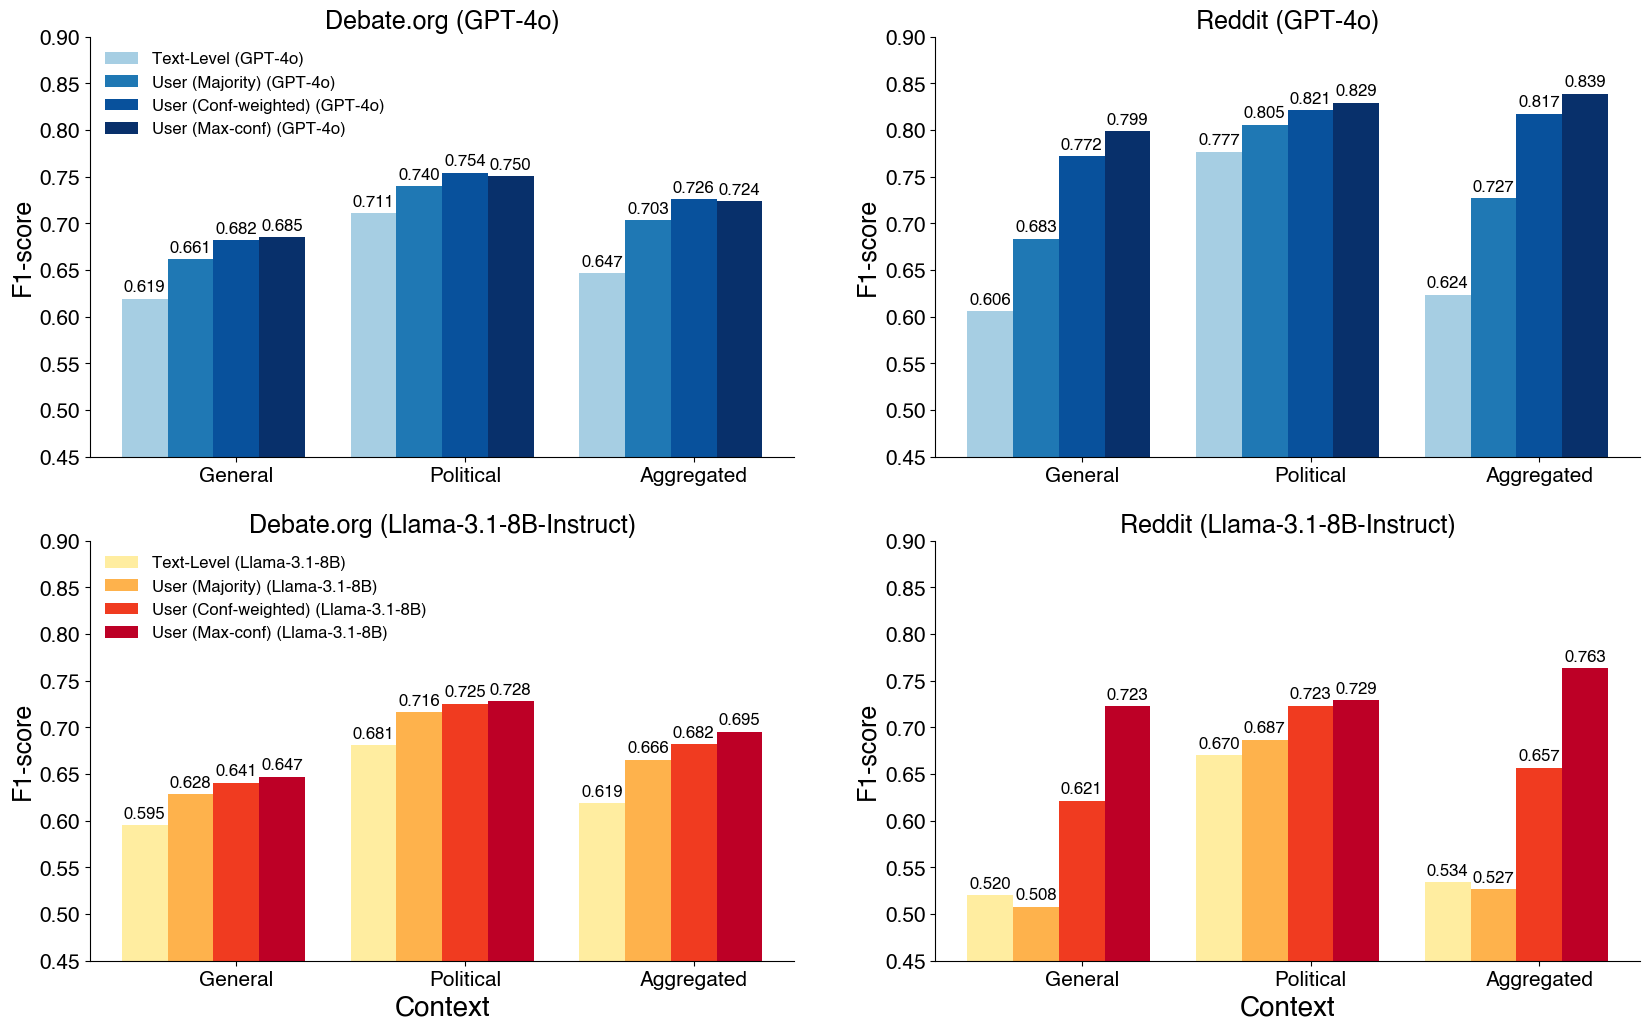

In [14]:
plt.rcParams.update({'font.size': 15})

# generate 2x2 subplots 
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# set width of each bar  
bar_width = 0.2
colors_gpt4o = ['#a6cee3', '#1f78b4', '#08519c', '#08306b'] 
colors_llama = ['#ffeda0', '#feb24c', '#f03b20', '#bd0026']  

# Debate.org data
debate_org_df = df[df['Dataset'].str.contains("Debate.org")]
contexts = ['General', 'Political', 'Aggregated']
debate_org_df = debate_org_df.set_index('Context').loc[contexts].reset_index()

x = np.arange(len(contexts))

# Reddit data
reddit_df = df[df['Dataset'].str.contains("Reddit")]
reddit_df = reddit_df.set_index('Context').loc[contexts].reset_index()

# ploting bar graphs 
# GPT-4o - Debate.org
axes[0, 0].bar(x - 2 * bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['Text-level F1-score'], 
               width=bar_width, color=colors_gpt4o[0], label='Text-Level (GPT-4o)')
axes[0, 0].bar(x - bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['User-level F1-score'], 
               width=bar_width, color=colors_gpt4o[1], label='User (Majority) (GPT-4o)')
axes[0, 0].bar(x, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_gpt4o[2], label='User (Conf-weighted) (GPT-4o)')
axes[0, 0].bar(x + bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_gpt4o[3], label='User (Max-conf) (GPT-4o)')

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(contexts, fontsize=15)
axes[0, 0].set_title('Debate.org (GPT-4o)', fontsize=18, fontweight='bold')
axes[0, 0].set_ylabel('F1-score', fontsize=18)
axes[0, 0].legend(loc=2, fontsize=12, frameon=False)  # legend 

# GPT-4o - Reddit
axes[0, 1].bar(x - 2 * bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['Text-level F1-score'], 
               width=bar_width, color=colors_gpt4o[0], label='Text-Level (GPT-4o)')
axes[0, 1].bar(x - bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['User-level F1-score'], 
               width=bar_width, color=colors_gpt4o[1], label='User (Majority) (GPT-4o)')
axes[0, 1].bar(x, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_gpt4o[2], label='User (Conf-weighted) (GPT-4o)')
axes[0, 1].bar(x + bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_gpt4o[3], label='User (Max-conf) (GPT-4o)')

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(contexts, fontsize=15)
axes[0, 1].set_title('Reddit (GPT-4o)', fontsize=18, fontweight='bold')
axes[0, 1].set_ylabel('F1-score', fontsize=18)


# Llama-3.2-8B - Debate.org
axes[1, 0].bar(x - 2 * bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['Text-level F1-score'], 
               width=bar_width, color=colors_llama[0], label='Text-Level (Llama-3.1-8B)')
axes[1, 0].bar(x - bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['User-level F1-score'], 
               width=bar_width, color=colors_llama[1], label='User (Majority) (Llama-3.1-8B)')
axes[1, 0].bar(x, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_llama[2], label='User (Conf-weighted) (Llama-3.1-8B)')
axes[1, 0].bar(x + bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_llama[3], label='User (Max-conf) (Llama-3.1-8B)')

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(contexts, fontsize=15)
axes[1, 0].set_title('Debate.org (Llama-3.1-8B-Instruct)', fontsize=18, fontweight='bold')
axes[1, 0].set_ylabel('F1-score', fontsize=18)
axes[1, 0].set_xlabel('Context', fontsize=20)
axes[1, 0].legend(loc=2, fontsize=12, frameon=False)  # legend

# Llama-3.2-3B - Reddit
axes[1, 1].bar(x - 2 * bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['Text-level F1-score'], 
               width=bar_width, color=colors_llama[0], label='Text-Level (Llama-3.1-8B)')
axes[1, 1].bar(x - bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['User-level F1-score'], 
               width=bar_width, color=colors_llama[1], label='User (Majority) (Llama-3.1-8B)')
axes[1, 1].bar(x, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_llama[2], label='User (Conf-weighted) (Llama-3.1-8B)')
axes[1, 1].bar(x + bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_llama[3], label='User (Max-conf) (Llama-3.1-8B)')

axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(contexts, fontsize=15)
axes[1, 1].set_title('Reddit (Llama-3.1-8B-Instruct)', fontsize=18, fontweight='bold')
axes[1, 1].set_ylabel('F1-score', fontsize=18)
axes[1, 1].set_xlabel('Context', fontsize=20)

for i in range(2):
    for j in range(2):
        ax = axes[i,j]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.grid(True, which='major', axis='y',linestyle='--', linewidth=0.5)
        ax.set_ylim(0.45,0.9)
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', fontsize=12, padding=3)

plt.show()


# Inference performance across categories

## Calculation of inference performance across categories

### DDO - F1 matrix (categories vs F1 scores)

In [7]:
category_list = list(data_ddo.value_counts('debate_category').index)
category_list, len(category_list)

(['Politics',
  'Religion',
  'Society',
  'Miscellaneous',
  'Entertainment',
  'Education',
  'Science',
  'Philosophy',
  'Health',
  'Sports',
  'Economics',
  'People',
  'Technology',
  'Games',
  'Funny',
  'Arts',
  'News',
  'Music',
  'Movies',
  'TV',
  'Cars',
  'Places-Travel',
  'Fashion'],
 23)

In [11]:
#DDO - GPT results 
matrix_ddo_gpt = np.zeros((len(category_list), 5))

for idx, cat in enumerate(category_list):

    result = util.user_level_category_f1(data_ddo, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o', category_label='debate_category', category=cat )
    
    for i in range(len(result)):
        matrix_ddo_gpt[idx, i] = result[i]

#DDO - llama results 
matrix_ddo_llama = np.zeros((len(category_list), 5))

for idx, cat in enumerate(category_list):
    
    result = util.user_level_category_f1(data_ddo, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b', category_label='debate_category', category=cat )
    
    for i in range(len(result)):
        matrix_ddo_llama[idx, i] = result[i]        

In [12]:
catf1_ddo_gpt = pd.DataFrame(matrix_ddo_gpt, index=category_list, columns=['text-level', 'user_simple', 'user_conf-weighted', 'user_conf-max', 'category_size'])
catf1_ddo_llama = pd.DataFrame(matrix_ddo_llama, index=category_list, columns=['text-level', 'user_simple', 'user_conf-weighted', 'user_conf-max','category_size'])

In [15]:
print(catf1_ddo_gpt.shape, catf1_ddo_llama.shape)
catf1_ddo_gpt.head()

(23, 5) (23, 5)


,text-level,user_simple,user_conf-weighted,user_conf-max,category_size
Politics,0.710674,0.739892,0.754039,0.750291,6045.0
Religion,0.714356,0.746377,0.746139,0.742060,2329.0
Society,0.659671,0.665725,0.689979,0.686835,2195.0
Miscellaneous,0.573214,0.596704,0.605625,0.615291,1808.0
Entertainment,0.513624,0.496137,0.511786,0.516942,1101.0


In [24]:
import os

os.makedirs('./data/category_f1scores', exist_ok=True)

In [26]:
catf1_ddo_gpt.to_parquet('./data/category_f1scores/catf1_ddo_gpt.parquet')
catf1_ddo_llama.to_parquet('./data/category_f1scores/catf1_ddo_llama.parquet')

### Reddit - F1 matrix (Category vs. F1 scores)

In [28]:
category_list_reddit = list(data_reddit.value_counts('inferred_category').index)

In [30]:
## Reddit GPT result
matrix_reddit_gpt = np.zeros((len(category_list_reddit), 5))

for idx, cat in enumerate(category_list_reddit):

    result = util.user_level_category_f1(data_reddit, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o', category_label='inferred_category', category=cat )
     
    for i in range(len(result)):
        matrix_reddit_gpt[idx, i] = result[i]

## Reddit llama result
matrix_reddit_llama = np.zeros((len(category_list_reddit), 5))

for idx, cat in enumerate(category_list_reddit):
    
    result = util.user_level_category_f1(data_reddit, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b', category_label='inferred_category', category=cat )
    
    for i in range(len(result)):
        matrix_reddit_llama[idx, i] = result[i]        

In [31]:
catf1_reddit_gpt = pd.DataFrame(matrix_reddit_gpt, index=category_list_reddit, columns=['text-level', 'user_simple', 'user_conf-weighted', 'user_conf-max', 'category_size'])
catf1_reddit_llama = pd.DataFrame(matrix_reddit_llama, index=category_list_reddit, columns=['text-level', 'user_simple', 'user_conf-weighted', 'user_conf-max','category_size'])

In [32]:
catf1_reddit_gpt.to_parquet('./data/category_f1scores/catf1_reddit_gpt.parquet')
catf1_reddit_llama.to_parquet('./data/category_f1scores/catf1_reddit_llama.parquet')

## Plotting the relation (Figure 2)

In [34]:
catf1_ddo_gpt   = pd.read_parquet('./data/category_f1scores/catf1_ddo_gpt.parquet')
catf1_ddo_llama = pd.read_parquet('./data/category_f1scores/catf1_ddo_llama.parquet')

catf1_reddit_gpt   = pd.read_parquet('./data/category_f1scores/catf1_reddit_gpt.parquet')
catf1_reddit_llama = pd.read_parquet('./data/category_f1scores/catf1_reddit_llama.parquet')

In [36]:
catf1_ddo_gpt.head()

,text-level,user_simple,user_conf-weighted,user_conf-max,category_size
Politics,0.710674,0.739892,0.754039,0.750291,6045.0
Religion,0.714356,0.746377,0.746139,0.742060,2329.0
Society,0.659671,0.665725,0.689979,0.686835,2195.0
Miscellaneous,0.573214,0.596704,0.605625,0.615291,1808.0
Entertainment,0.513624,0.496137,0.511786,0.516942,1101.0


In [38]:
#sort categories based on f1 score of gpt
catf1_ddo_gpt = catf1_ddo_gpt.sort_values(by='user_conf-max', ascending=False)
sorted_index = catf1_ddo_gpt.index 
catf1_ddo_llama = catf1_ddo_llama.reindex(sorted_index)

catf1_reddit_gpt = catf1_reddit_gpt.sort_values(by='user_conf-max', ascending=False)
sorted_index = catf1_reddit_gpt.index 
catf1_reddit_llama = catf1_reddit_llama.reindex(sorted_index)

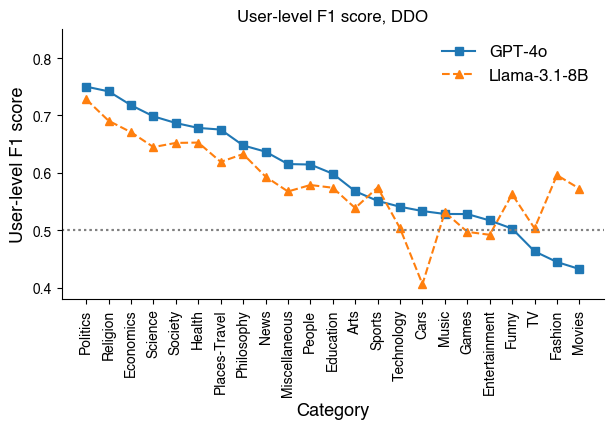

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))

# Plot for GPT-4o
ax.plot(catf1_ddo_gpt.index, catf1_ddo_gpt['user_conf-max'], 's-', label='GPT-4o')
ax.axhline(0.5, ls=':', color='gray')
ax.tick_params(axis='x', rotation=90)

# Plot for Llama-3.1-8B-Instruct
ax.plot(catf1_ddo_llama.index, catf1_ddo_llama['user_conf-max'], '^--', label='Llama-3.1-8B')
ax.axhline(0.5, ls=':', color='gray')
ax.tick_params(axis='x', rotation=90)

ax.set_xlabel('Category', fontsize=13)
ax.set_ylabel('User-level F1 score', fontsize=13)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim(0.38, 0.85)
ax.set_title('User-level F1 score, DDO')

plt.legend(frameon=False, fontsize=12)

#plt.savefig('../fig/figs_for_paper/Fig2_source/aggregated/DDO-user.pdf', transparent=True, bbox_inches='tight')
plt.show()

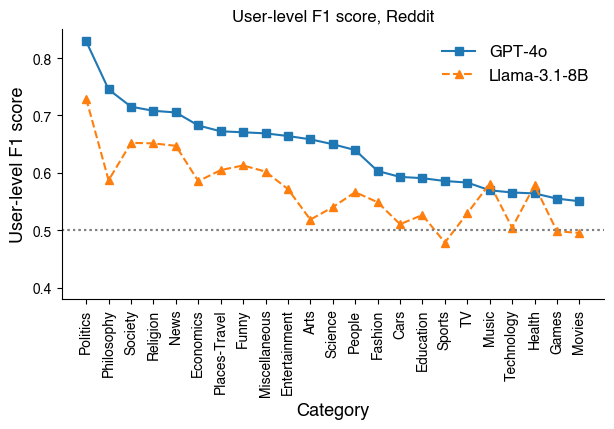

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))

# Plot for GPT-4o
ax.plot(catf1_reddit_gpt.index, catf1_reddit_gpt['user_conf-max'], 's-', label='GPT-4o')
ax.axhline(0.5, ls=':', color='gray')
ax.tick_params(axis='x', rotation=90)

# Plot for Llama-3.1-8B-Instruct
ax.plot(catf1_reddit_llama.index, catf1_reddit_llama['user_conf-max'], '^--', label='Llama-3.1-8B')
ax.axhline(0.5, ls=':', color='gray')
ax.tick_params(axis='x', rotation=90)

ax.set_xlabel('Category', fontsize=13)
ax.set_ylabel('User-level F1 score', fontsize=13)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_title('User-level F1 score, Reddit')
ax.set_ylim(0.38, 0.85)

plt.legend(frameon=False, fontsize=12)
#plt.savefig('../fig/figs_for_paper/Fig2_source/aggregated/Reddit-user.pdf', transparent=True, bbox_inches='tight')
plt.show()

## Congruence across models and datasets (Figure 2c-f)

In [41]:
category2colors = {
    'Politics': '#4C72B0',       # Deep Blue
    'Religion': '#DD8452',       # Warm Orange
    'Economics': '#55A868',      # Fresh Green
    'Science': '#C44E52',        # Rich Red
    'Health': '#8172B2',         # Soft Purple
    'Society': '#937860',        # Muted Brown
    'Places-Travel': '#DA8BC3',  # Warm Pink
    'Philosophy': '#8C8C8C',     # Neutral Gray
    'News': '#CCB974',           # Warm Beige
    'People': '#64B5CD',         # Light Cyan
    'Miscellaneous': '#E377C2',  # Bright Pink
    'Education': '#A1C9F4',      # Soft Sky Blue
    'Arts': '#76B7B2',           # Muted Teal
    'Music': '#B07AA1',          # Soft Violet
    'Sports': '#F28E2B',         # Vivid Orange
    'Cars': '#FFCF56',           # Bright Yellow
    'Technology': '#60BD68',     # Bright Green
    'Entertainment': '#F17E59',  # Coral
    'Games': '#B5B5B5',          # Soft Gray
    'Funny': '#FABF62',          # Golden Yellow
    'TV': '#4596D3',             # Strong Blue
    'Movies': '#D9A8C7',         # Soft Mauve
    'Fashion': '#FF9DA7',        # Light Red-Pink
}


### Congruence across models (text level and user level)

#### DDO - GPT vs Llama

In [43]:
category_order = catf1_ddo_gpt.index
catf1_ddo_llama = catf1_ddo_llama.loc[category_order] #make the order same

#we take the average size 
#Otherwise we can set the size as the number of texts that are answered by both models.  
category_avgsize = (catf1_ddo_gpt['category_size'] + catf1_ddo_llama['category_size'])/2

category_colors = [category2colors[e] for e in category_order]

0.8502850098834683 2.7887471334738283e-07
0.7584627657894437 2.741038384691563e-05


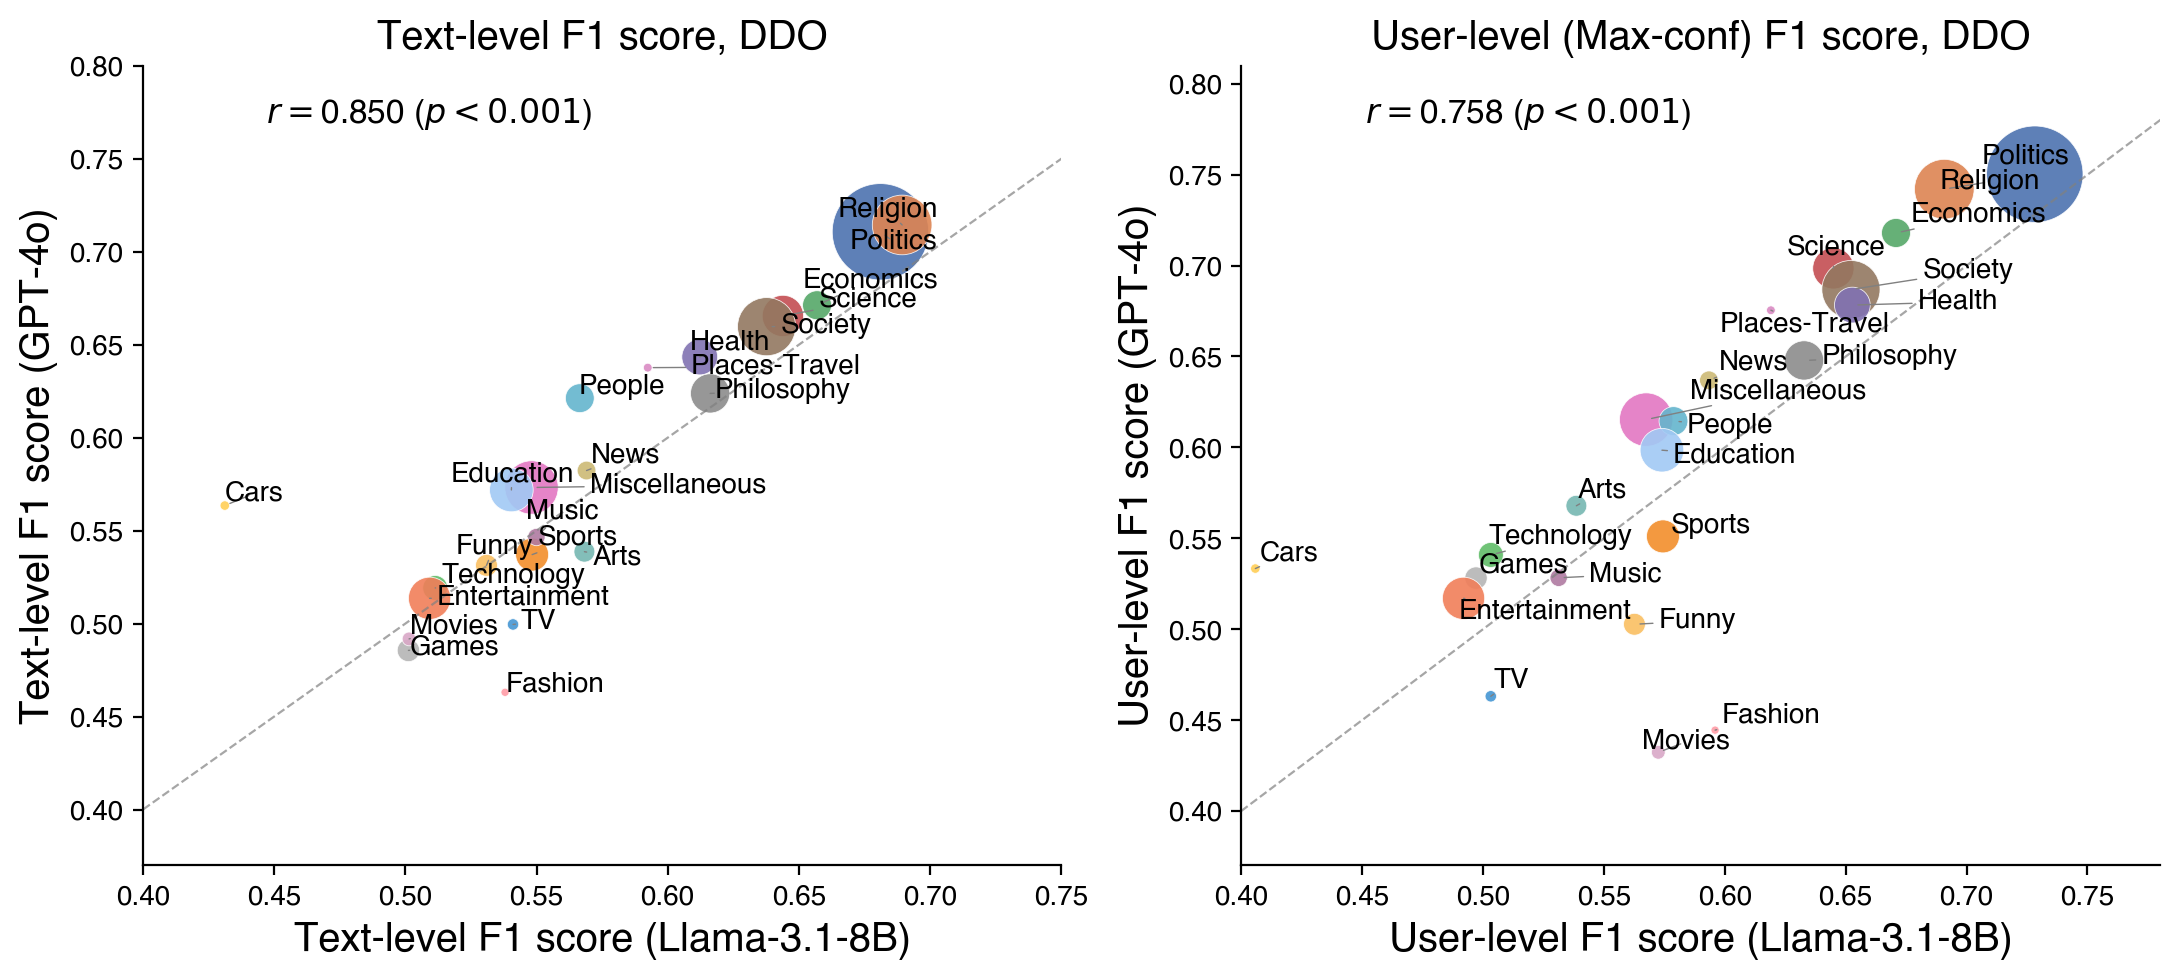

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=200)

#1. text-level accuracy axes[0]
sns.scatterplot(y=catf1_ddo_gpt['text-level'], x=catf1_ddo_llama['text-level'],
                s=category_avgsize*0.2, color=category_colors, alpha=.9, ax=axes[0])

texts = []
for i in range(len(category_order)):
    texts.append(axes[0].text(y=catf1_ddo_gpt['text-level'].iloc[i],
                          x=catf1_ddo_llama['text-level'].iloc[i], 
                          s=category_order[i], ha='left', va='bottom', fontsize='medium'))

# adjust_text 함수로 텍스트 조정
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=axes[0])

axes[0].set_title('Text-level F1 score, DDO',fontsize='x-large')
axes[0].set_ylabel('Text-level F1 score (GPT-4o)',fontsize='x-large')
axes[0].set_xlabel('Text-level F1 score (Llama-3.1-8B)',fontsize='x-large')

axes[0].plot(np.arange(0,1,0.01), np.arange(0,1,0.01), color='gray', ls='--', alpha=0.7, lw=.8)
axes[0].set_xlim(0.4,0.75)
axes[0].set_ylim(0.37,0.8)

r,p = stats.pearsonr(catf1_ddo_gpt['text-level'], catf1_ddo_llama['text-level'])
print(r, p)
axes[0].scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))
axes[0].legend(frameon=False, loc=2, fontsize=12)



# 2. User-level accuracy axes
sns.scatterplot(y=catf1_ddo_gpt['user_conf-max'], x=catf1_ddo_llama['user_conf-max'],
                s=category_avgsize*0.2, color=category_colors, alpha=.9, ax=axes[1])

texts = []
for i in range(len(category_order)):
    texts.append(axes[1].text(y=catf1_ddo_gpt['user_conf-max'].iloc[i],
                          x=catf1_ddo_llama['user_conf-max'].iloc[i], 
                          s=category_order[i], ha='left', va='bottom', fontsize='medium'))

# adjust_text 함수로 텍스트 조정
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=axes[1])

axes[1].set_title('User-level (Max-conf) F1 score, DDO',fontsize='x-large')
axes[1].set_ylabel('User-level F1 score (GPT-4o)',fontsize='x-large')
axes[1].set_xlabel('User-level F1 score (Llama-3.1-8B)',fontsize='x-large')

axes[1].plot(np.arange(0,1,0.01), np.arange(0,1,0.01), color='gray', ls='--', alpha=0.7, lw=.8)
axes[1].set_xlim(0.4, 0.78)
axes[1].set_ylim(0.37,0.81)

r,p = stats.pearsonr(catf1_ddo_gpt['user_conf-max'], catf1_ddo_llama['user_conf-max'])
print(r, p)
axes[1].scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))
axes[1].legend(frameon=False, loc=2, fontsize=12)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


plt.tight_layout()
#plt.savefig('../fig/figs_for_paper/Fig2_source/F1-score_by_category_scatterplot_DDO(gpt4o_llama8b).pdf', transparent=True, bbox_inches='tight')
plt.show()


#### Reddit - GPT vs Llama

In [51]:
category_order_reddit = catf1_reddit_gpt.index
catf1_reddit_llama = catf1_reddit_llama.loc[category_order_reddit] #make the order same

#we take the average size 
#Otherwise we can set the size as the number of texts that are answered by both models.  
category_avgsize_reddit = (catf1_reddit_gpt['category_size'] + catf1_reddit_llama['category_size'])/2
category_colors_reddit = [category2colors[e] for e in category_order_reddit]

0.8375894053301988 6.179746480626071e-07
0.8374874660425982 6.217643114887217e-07


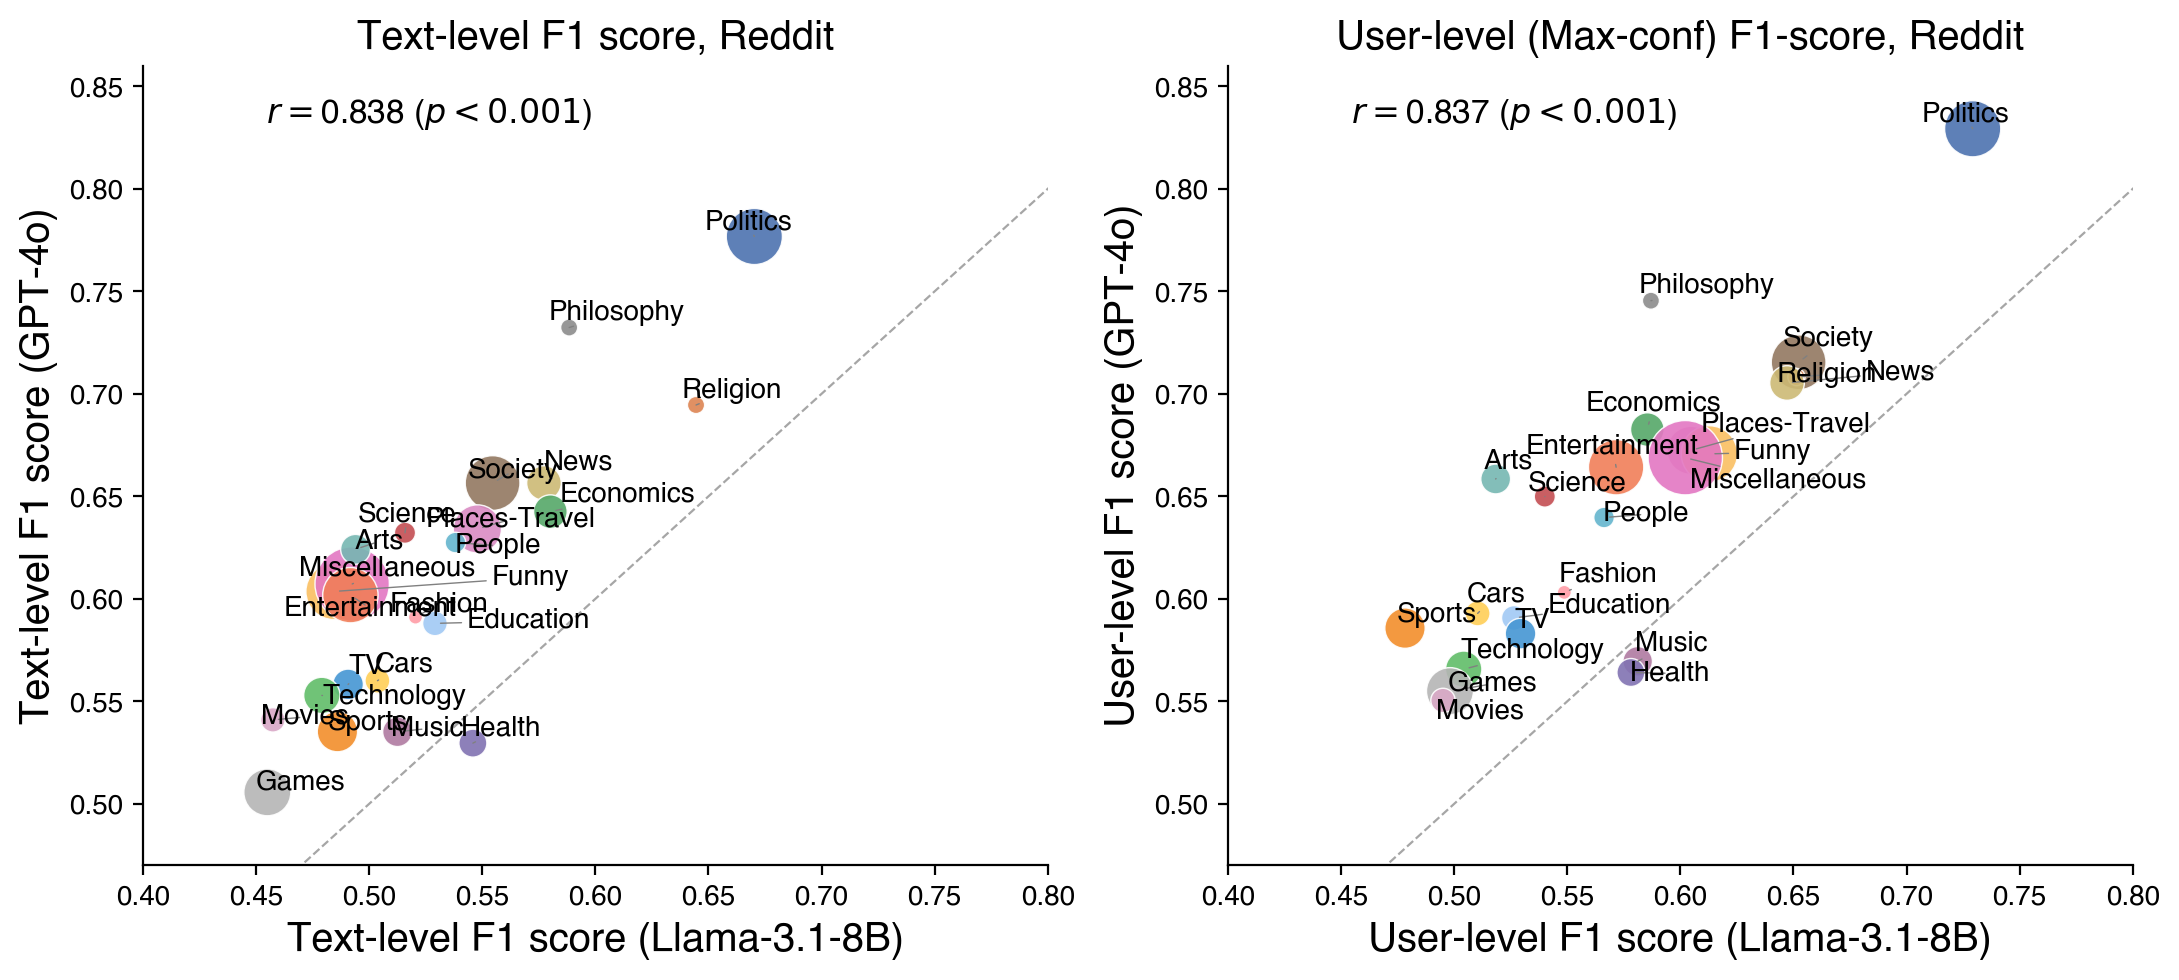

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=200)

#1. text-level accuracy axes[0]
sns.scatterplot(x=catf1_reddit_llama['text-level'],y=catf1_reddit_gpt['text-level'],
                s=category_avgsize_reddit*0.1, color=category_colors_reddit, alpha=0.9, ax=axes[0])

texts = []
for i in range(len(category_order_reddit)):
    texts.append(axes[0].text( x=catf1_reddit_llama['text-level'].iloc[i], y=catf1_reddit_gpt['text-level'].iloc[i],
                          s=category_order_reddit[i], ha='left', va='bottom', fontsize='medium'))

# adjust_text 함수로 텍스트 조정
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=axes[0])

axes[0].set_title('Text-level F1 score, Reddit',fontsize='x-large')
axes[0].set_ylabel('Text-level F1 score (GPT-4o)',fontsize='x-large')
axes[0].set_xlabel('Text-level F1 score (Llama-3.1-8B)',fontsize='x-large')

r,p = stats.pearsonr(catf1_reddit_llama['text-level'], catf1_reddit_gpt['text-level'])
print(r, p)
axes[0].scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))
axes[0].legend(frameon=False, loc=2, fontsize=12)



# 2. User-level accuracy axes
sns.scatterplot(x=catf1_reddit_llama['user_conf-max'],y=catf1_reddit_gpt['user_conf-max'], 
                s=category_avgsize_reddit*0.1, color=category_colors_reddit, alpha=0.9, ax=axes[1])

texts = []
for i in range(len(category_order)):

    texts.append(axes[1].text(x=catf1_reddit_llama['user_conf-max'].iloc[i], 
                              y=catf1_reddit_gpt['user_conf-max'].iloc[i],
                          s=category_order_reddit[i], ha='left', va='bottom', fontsize='medium'))

# adjust_text 함수로 텍스트 조정
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=axes[1])

axes[1].set_title('User-level (Max-conf) F1-score, Reddit',fontsize='x-large')
axes[1].set_ylabel('User-level F1 score (GPT-4o)',fontsize='x-large')
axes[1].set_xlabel('User-level F1 score (Llama-3.1-8B)',fontsize='x-large')

r,p = stats.pearsonr(catf1_reddit_llama['user_conf-max'], catf1_reddit_gpt['user_conf-max'])
print(r, p)
axes[1].scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))
axes[1].legend(frameon=False, loc=2, fontsize=12)


for ax in axes:
    ax.plot(np.arange(0,0.85,0.01), np.arange(0,.85,0.01), color='gray', ls='--', alpha=0.7, lw=0.8)
    ax.set_xlim(0.4,0.8)
    ax.set_ylim(0.47,0.86)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


plt.tight_layout()
#plt.savefig('../fig/figs_for_paper/Fig2_source/F1-score_by_category_scatterplot_Reddit(gpt4o_llama8b).pdf', transparent=True, bbox_inches='tight')
plt.show()


### Congruence across datasets

In [55]:
catf1_list = [catf1_ddo_gpt, catf1_reddit_gpt, catf1_ddo_llama, catf1_reddit_llama]
model_names = ['DDO, GPT-4o', 'Reddit, GPT-4o', 'DDO, Llama-3.1-8B', 'Reddit, Llama-3.1-8B']

cat_order = list(category2colors.keys())
cat_colors = list(category2colors.values())

#### Text-level F1 score correlation between two datasets

0.7039018946687553 0.00017815784172340126


/var/folders/r8/jdw1p2tj6jn34wf676kcsw_r0000gn/T/ipykernel_23811/3626729857.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(ax.text(x=gpt_ddo[i], y=gpt_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))


0.8058458413307162 3.4705410867158506e-06


/var/folders/r8/jdw1p2tj6jn34wf676kcsw_r0000gn/T/ipykernel_23811/3626729857.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(ax.text(x=llama_ddo[i], y=llama_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))


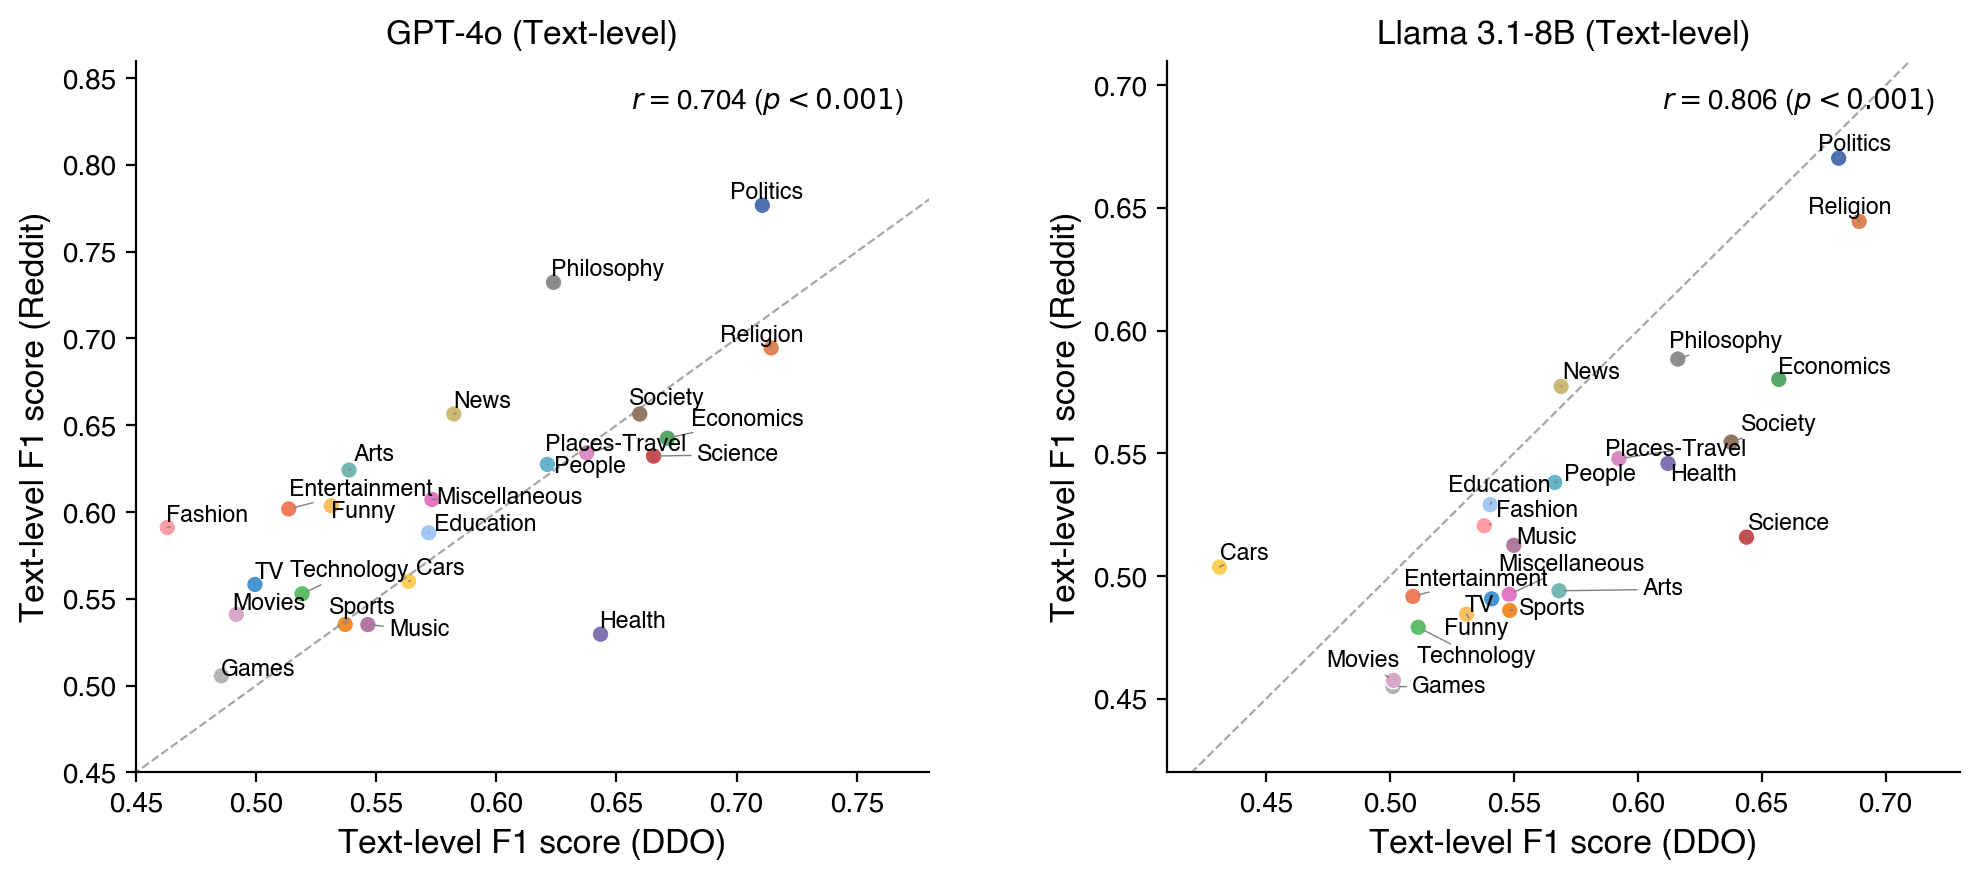

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=200)

#Text Level GPT_ddo vs gpt_reddit
ax = axes[0]
gpt_ddo = catf1_list[0].loc[cat_order]['text-level']
gpt_reddit = catf1_list[1].loc[cat_order]['text-level']

r,p = stats.pearsonr(gpt_ddo, gpt_reddit)
print(r, p)
sns.scatterplot(x=gpt_ddo, y=gpt_reddit, ax=ax, color=cat_colors)
ax.scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))

#Text labels 
texts = []
for i in range(len(cat_order)):
    texts.append(ax.text(x=gpt_ddo[i], y=gpt_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=ax)

#Labels
axes[0].set_title('GPT-4o (Text-level)',fontsize='large')
axes[0].set_ylabel('Text-level F1 score (Reddit)', fontsize='large')
axes[0].set_xlabel('Text-level F1 score (DDO)',fontsize='large')

axes[0].plot(np.arange(0,0.85,0.01), np.arange(0,.85,0.01), color='gray', ls='--', alpha=0.7, lw=0.8)

axes[0].set_xlim(0.45,0.78)
axes[0].set_ylim(0.45,0.86)
ax.legend(frameon=False, loc=1)



#ax.axvline(0.5, ls='--', color='gray', lw=.7)
#ax.axhline(0.5, ls='--', color='gray', lw=.7)


#Text Level Llama_ddo vs llama_reddit
ax = axes[1]

llama_ddo = catf1_list[2].loc[cat_order]['text-level']
llama_reddit = catf1_list[3].loc[cat_order]['text-level']
r,p = stats.pearsonr(llama_ddo, llama_reddit)
print(r, p)

sns.scatterplot(x=llama_ddo, y=llama_reddit, ax=ax, color=cat_colors)
ax.scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))

#Text labels 
texts = []
for i in range(len(cat_order)):
    texts.append(ax.text(x=llama_ddo[i], y=llama_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=ax)

#Labels
axes[1].set_title('Llama 3.1-8B (Text-level)',fontsize='large')
axes[1].set_ylabel('Text-level F1 score (Reddit)', fontsize='large')
axes[1].set_xlabel('Text-level F1 score (DDO)',fontsize='large')

axes[1].plot(np.arange(0,0.85,0.01), np.arange(0,.85,0.01), color='gray', ls='--', alpha=0.7, lw=0.8)

axes[1].set_xlim(0.41,0.73)
axes[1].set_ylim(0.42,0.71)
ax.legend(frameon=False, loc=1)
#ax.axvline(0.5, ls='--', color='gray', lw=.7)
#ax.axhline(0.5, ls='--', color='gray', lw=.7)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
#plt.savefig('../fig/figs_for_paper/Fig2_source/F1_correlation_between_data_Text-level(gpt4o_llama8b).pdf', transparent=True, bbox_inches='tight')
plt.show()

#### User-level F1 score correlation between two datasets

0.6730463600729006 0.00043251569638532415


/var/folders/r8/jdw1p2tj6jn34wf676kcsw_r0000gn/T/ipykernel_23811/4137047588.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(ax.text(x=gpt_ddo[i], y=gpt_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))


0.6646210741970277 0.0005415069226072406


/var/folders/r8/jdw1p2tj6jn34wf676kcsw_r0000gn/T/ipykernel_23811/4137047588.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(ax.text(x=gpt_ddo[i], y=gpt_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))


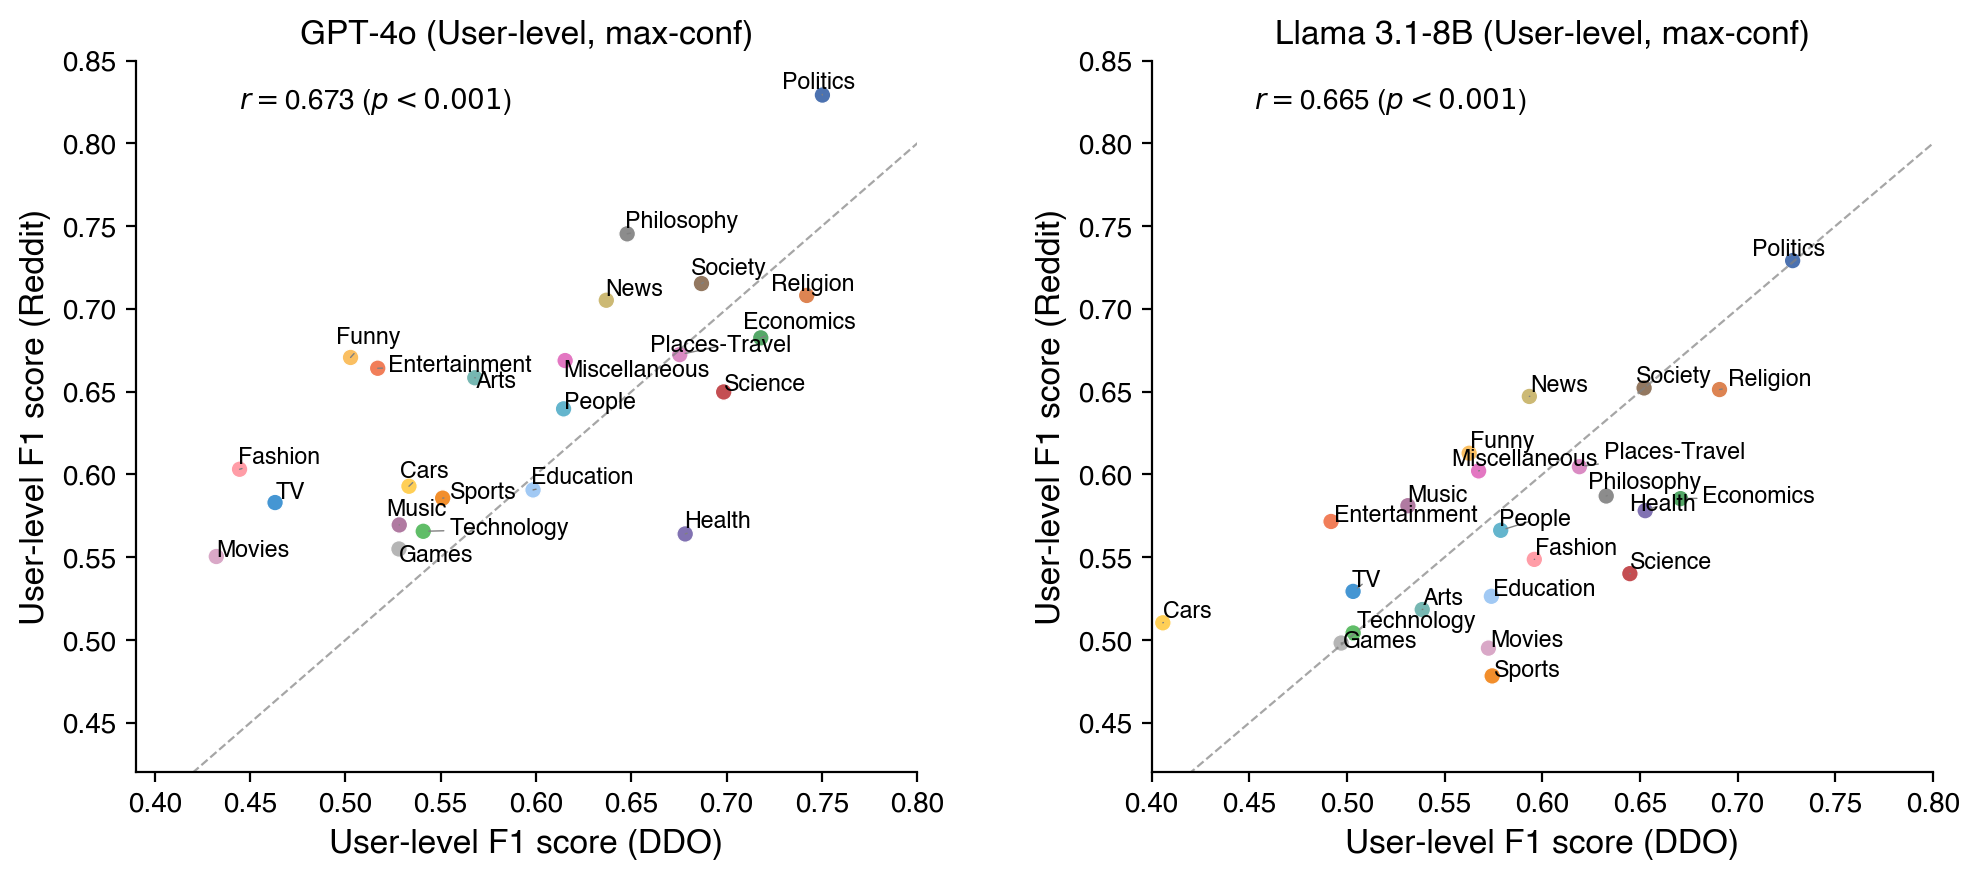

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=200)


#Text Level
ax = axes[0]
gpt_ddo = catf1_list[0].loc[cat_order]['user_conf-max']
gpt_reddit = catf1_list[1].loc[cat_order]['user_conf-max']

r,p = stats.pearsonr(gpt_ddo, gpt_reddit)
print(r, p)

sns.scatterplot(x=gpt_ddo, y=gpt_reddit, ax=ax, color=cat_colors)
ax.scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))

sns.scatterplot(x=gpt_ddo, y=gpt_reddit, ax=ax, color=cat_colors)

#Text labels 
texts = []
for i in range(len(cat_order)):
    texts.append(ax.text(x=gpt_ddo[i], y=gpt_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=ax)

#Labels
axes[0].set_title('GPT-4o (User-level, max-conf)',fontsize='large')
axes[0].set_ylabel('User-level F1 score (Reddit)', fontsize='large')
axes[0].set_xlabel('User-level F1 score (DDO)',fontsize='large')

axes[0].plot(np.arange(0,0.85,0.01), np.arange(0,.85,0.01), color='gray', ls='--', alpha=0.7, lw=0.8)

axes[0].set_xlim(0.39,0.8)
axes[0].set_ylim(0.42,0.85)

ax.legend(frameon=False, loc=2)
#ax.axvline(0.5, ls='--', color='gray', lw=.7)
#ax.axhline(0.5, ls='--', color='gray', lw=.7)

#Llama
ax = axes[1]

gpt_ddo = catf1_list[2].loc[cat_order]['user_conf-max']
gpt_reddit = catf1_list[3].loc[cat_order]['user_conf-max']

r,p = stats.pearsonr(gpt_ddo, gpt_reddit)
print(r, p)

sns.scatterplot(x=gpt_ddo, y=gpt_reddit, ax=ax, color=cat_colors)
ax.scatter([],[],s=0,label=r'$r=$%.3f ($p<0.001$)'%(r))


sns.scatterplot(x=gpt_ddo, y=gpt_reddit, ax=ax, color=cat_colors)

#Text labels 
texts = []
for i in range(len(cat_order)):
    texts.append(ax.text(x=gpt_ddo[i], y=gpt_reddit[i], s=cat_order[i], ha='left', va='bottom', fontsize='small'))
adjust_text(texts, only_move={'points': 'y', 'texts': 'xy'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=ax)

#Labels
axes[1].set_title('Llama 3.1-8B (User-level, max-conf)',fontsize='large')
axes[1].set_ylabel('User-level F1 score (Reddit)', fontsize='large')
axes[1].set_xlabel('User-level F1 score (DDO)',fontsize='large')

axes[1].plot(np.arange(0,0.85,0.01), np.arange(0,.85,0.01), color='gray', ls='--', alpha=0.7, lw=0.8)

axes[1].set_xlim(0.4,0.8)
axes[1].set_ylim(0.42,0.85)
#ax.axvline(0.5, ls='--', color='gray', lw=.7)
#ax.axhline(0.5, ls='--', color='gray', lw=.7)
ax.legend(frameon=False, loc=2)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
#plt.savefig('../fig/figs_for_paper/Fig2_source/F1_correlation_between_data_User-level(gpt4o_llama8b).pdf', transparent=True, bbox_inches='tight')
plt.show()

# Effects of semantic and social proximity on political inference

## User similarity

In [59]:
category2users_ddo = {}
for cat, dat in data_ddo.groupby('debate_category'):
    category2users_ddo[cat] = set(dat['user_name'].unique())

### DDO - Jaccard similarity and NPMI

output: jaccard_matrix, pmi_matrix

In [81]:
from itertools import combinations

# Initialize matrices
categories = list(category2users_ddo.keys())
n = len(categories)
jaccard_matrix = np.zeros((n, n))
pmi_matrix = np.zeros((n, n))

# Calculate total number of unique users across all categories
total_users = len(set().union(*category2users_ddo.values()))

# Calculate Jaccard similarity and PMI for each category pair
for i, j in combinations(range(n), 2):
    set_i = set(category2users_ddo[categories[i]])
    set_j = set(category2users_ddo[categories[j]])
    
    jaccard_matrix[i, j] = util.calculate_jaccard(set_i, set_j)
    jaccard_matrix[j, i] = jaccard_matrix[i, j]  # Symmetric
    
    pmi_matrix[i, j] = util.calculate_npmi(set_i, set_j, total_users)
    pmi_matrix[j, i] = pmi_matrix[i, j]  # Symmetric

# If you want to include diagonal elements, you can set them explicitly.
for i in range(n):
    set_i = set(category2users_ddo[categories[i]])
    jaccard_matrix[i, i] = util.calculate_jaccard(set_i, set_i)  # Jaccard of a set with itself is 1
    pmi_matrix[i, i] = util.calculate_npmi(set_i, set_i, total_users)  # PMI is generally considered 0 for identical sets


In [82]:
# Identify the index of the "politics" category
politics_index = categories.index("Politics")

# Sort categories based on Jaccard similarity with "politics"
sorted_indices = np.argsort(-jaccard_matrix[politics_index, :])  # Negative for descending order
sorted_categories = [categories[i] for i in sorted_indices]

category2indices = {}
for cat, idx in zip(sorted_categories, sorted_indices):
    category2indices[cat] = idx 

# extract user level f1 scores
cat2f1_cmax_gpt = catf1_ddo_gpt['user_conf-max'].to_dict()
cat2f1_cmax_llama = catf1_ddo_llama['user_conf-max'].to_dict()

jac_with_pol = [jaccard_matrix[politics_index, category2indices[cat] ] for cat in category2indices if cat != 'Politics'] 
f1_cmax_gpt = [cat2f1_cmax_gpt[cat] for cat in category2indices if cat != 'Politics']
f1_cmax_llama = [cat2f1_cmax_llama[cat] for cat in category2indices if cat != 'Politics']
cat_labels = [cat for cat in category2indices if cat != 'Politics']

#### DDO - Jaccard similarity (gpt, llama)

In [83]:
df_jaccard = pd.DataFrame({'category': cat_labels, 'jaccard_sim': jac_with_pol, 'f1_gpt':f1_cmax_gpt, 'f1_llama': f1_cmax_llama, })

os.makedirs('./data/similarity_analysis', exist_ok=True)
df_jaccard.to_csv('./data/similarity_analysis/jaccard_data_ddo.csv')

df_jaccard.head()

,category,jaccard_sim,f1_gpt,f1_llama
0,Society,0.259937,0.686835,0.652161
1,Religion,0.246292,0.742060,0.690771
2,Miscellaneous,0.201296,0.615291,0.567450
3,Education,0.190939,0.598454,0.573973
4,Science,0.172992,0.698490,0.644889


#### DDO - NPMI (gpt, llama)

In [85]:
# Identify the index of the "politics" category
politics_index = categories.index("Politics")

In [86]:
pmi_with_pol = [pmi_matrix[politics_index, category2indices[cat] ] for cat in category2indices if cat != 'Politics'] 
f1_cmax_gpt = [cat2f1_cmax_gpt[cat] for cat in category2indices if cat != 'Politics']
f1_cmax_llama = [cat2f1_cmax_llama[cat] for cat in category2indices if cat != 'Politics']
cat_labels = [cat for cat in category2indices if cat != 'Politics']

In [87]:
df_npmi = pd.DataFrame({'category': cat_labels, 'npmi': pmi_with_pol, 'f1_gpt':f1_cmax_gpt, 'f1_llama': f1_cmax_llama, })
df_npmi.to_csv('./data/similarity_analysis/npmi_data_ddo.csv')
df_npmi.head()

,category,npmi,f1_gpt,f1_llama
0,Society,0.072521,0.686835,0.652161
1,Religion,0.065144,0.742060,0.690771
2,Miscellaneous,0.049679,0.615291,0.567450
3,Education,0.036975,0.598454,0.573973
4,Science,0.101039,0.698490,0.644889


### Reddit - Jaccard similarity and NPMI

In [89]:
category2users_reddit = {}
for cat, dat in data_reddit.groupby('inferred_category'):
    category2users_reddit[cat] = set(dat['user_name'].unique())

In [93]:
# Initialize matrices
categories = list(category2users_reddit.keys())
n = len(categories)
jaccard_matrix = np.zeros((n, n))
pmi_matrix = np.zeros((n, n))

# Calculate total number of unique users across all categories
total_users = len(set().union(*category2users_reddit.values()))

# Calculate Jaccard similarity and PMI for each category pair
for i, j in combinations(range(n), 2):
    set_i = set(category2users_reddit[categories[i]])
    set_j = set(category2users_reddit[categories[j]])
    
    jaccard_matrix[i, j] = util.calculate_jaccard(set_i, set_j)
    jaccard_matrix[j, i] = jaccard_matrix[i, j]  # Symmetric
    
    pmi_matrix[i, j] = util.calculate_npmi(set_i, set_j, total_users)
    pmi_matrix[j, i] = pmi_matrix[i, j]  # Symmetric

# If you want to include diagonal elements, you can set them explicitly.
for i in range(n):
    set_i = set(category2users_reddit[categories[i]])
    jaccard_matrix[i, i] = util.calculate_jaccard(set_i, set_i)  # Jaccard of a set with itself is 1
    pmi_matrix[i, i] = util.calculate_npmi(set_i, set_i, total_users)  # PMI is generally considered 0 for identical sets

# Now, jaccard_matrix and pmi_matrix are filled with the calculated values.
politics_index = categories.index("Politics")
politics_index

16

In [95]:
sorted_indices = np.argsort(-jaccard_matrix[politics_index, :])  # Negative for descending order
sorted_categories = [categories[i] for i in sorted_indices]

sorted_similarity = jaccard_matrix[politics_index, sorted_indices]

In [96]:
cat2f1_cmax_reddit_gpt = catf1_reddit_gpt['user_conf-max'].to_dict()
cat2f1_cmax_reddit_llama = catf1_reddit_llama['user_conf-max'].to_dict()

jac_with_pol = [jaccard_matrix[politics_index, category2indices[cat] ] for cat in category2indices if cat != 'Politics'] 
f1_cmax_reddit_gpt = [cat2f1_cmax_reddit_gpt[cat] for cat in category2indices if cat != 'Politics']
f1_cmax_reddit_llama = [cat2f1_cmax_reddit_llama[cat] for cat in category2indices if cat != 'Politics']
cat_labels = [cat for cat in category2indices if cat != 'Politics']

In [97]:
df_jaccard_reddit = pd.DataFrame({'category': cat_labels, 'jaccard_sim': jac_with_pol, 'f1_gpt':f1_cmax_reddit_gpt, 'f1_llama': f1_cmax_reddit_llama})
df_jaccard_reddit.to_csv('./data/similarity_analysis/jaccard_data_reddit.csv')
df_jaccard_reddit.head()

,category,jaccard_sim,f1_gpt,f1_llama
0,Society,0.632664,0.715350,0.652280
1,Religion,0.155752,0.708156,0.651316
2,Miscellaneous,0.736054,0.668827,0.602180
3,Education,0.280481,0.590682,0.526425
4,Science,0.218859,0.649867,0.540099


In [98]:
# Identify the index of the "politics" category
politics_index = categories.index("Politics")

# Sort categories based on Jaccard similarity with "politics"
sorted_indices = np.argsort(-pmi_matrix[politics_index, :])  # Negative for descending order
sorted_categories = [categories[i] for i in sorted_indices]

sorted_similarity = pmi_matrix[politics_index, sorted_indices]
sorted_similarity

array([ 1.00000000e+00,  6.18321614e-02,  4.16069651e-02,  3.98272041e-02,
        3.34317253e-02,  2.81037423e-02,  2.75775746e-02,  2.72599043e-02,
        2.22918144e-02,  2.14215630e-02,  2.01303410e-02,  1.72064347e-02,
        1.57983505e-02,  1.26601134e-02,  1.06780956e-02,  9.95076370e-03,
        8.75784564e-03,  4.89379228e-03,  4.87282176e-03,  3.28865641e-03,
        2.29982520e-04, -1.01339510e-02, -4.22563361e-02])

In [99]:
pmi_with_pol = [pmi_matrix[politics_index, category2indices[cat] ] for cat in category2indices if cat != 'Politics'] 
f1_cmax_reddit_gpt = [cat2f1_cmax_reddit_gpt[cat] for cat in category2indices if cat != 'Politics']
f1_cmax_reddit_llama = [cat2f1_cmax_reddit_llama[cat] for cat in category2indices if cat != 'Politics']
cat_labels = [cat for cat in category2indices if cat != 'Politics']

In [100]:
df_jaccard_reddit = pd.DataFrame({'category': cat_labels, 'npmi': pmi_with_pol, 'f1_gpt':f1_cmax_reddit_gpt, 'f1_llama': f1_cmax_reddit_llama})
df_jaccard_reddit.to_csv('./data/similarity_analysis/npmi_data_reddit.csv')
df_jaccard_reddit.head()

,category,npmi,f1_gpt,f1_llama
0,Society,0.009951,0.715350,0.652280
1,Religion,0.027260,0.708156,0.651316
2,Miscellaneous,0.015798,0.668827,0.602180
3,Education,0.012660,0.590682,0.526425
4,Science,0.022292,0.649867,0.540099


## Semantic similarity (title and content embedding similarity)

In [13]:
#!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
tqdm.pandas()

In [14]:
model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2',
    device='cpu' # or "cuda:1"
)

print("test result (encoding a sentence into a vector) dim: ", model.encode("Test sentence").shape)

test result (encoding a sentence into a vector) dim:  (768,)


In [21]:
#example
print(model.encode(data_ddo['context'].iloc[0]).shape)

(768,)


 * by using above transformer one can get 768 dim vector representation of the texts (context and title for DDO and subreddit description and context for Reddit dataset)
  
```
data_ddo['title_embedding'] = data_ddo['debate_title'].progress_apply(lambda x: model.encode(x))
data_ddo['context_embedding'] = data_ddo['context'].progress_apply(lambda x: model.encode(x))
```

 * Since encoding all context and titles within two datasets into vectors takes 2-3 hours using CPU, we use pre-calculated embedding vectors. 

### DDO title and context embedding

In [23]:
data_ddo.head(2)

,user_name,debate_title,debate_texts,party,party_short,debate_category,context,num_token,short_text,num_token_short,party_out_gpt4o,confidence_gpt4o,party_out_llama8b,confidence_llama8b,clean_text,title_embedding,context_embedding
0,0092678,is french horn better than clarinet in intelle...,[\n \n this is my first debate so i dont exp...,Democratic Party,Democratic,Arts,Debate title: is french horn better than clari...,98,Debate title: is french horn better than clari...,98,Democratic,1.0,Republican,1.0,french horn better clarinet intellectual state...,"[-0.013753281, 0.01767441, -0.04131594, 0.0125...","[0.008170005, 0.021220889, -0.011992658, 0.019..."
1,0092678,"what makes wings so amazing (buffalo wings, tr...","[\n \n i dissagree, forfeit, \n \n still d...",Democratic Party,Democratic,Miscellaneous,Debate title: what makes wings so amazing (buf...,50,Debate title: what makes wings so amazing (buf...,50,Republican,1.0,Republican,1.0,makes wings amazing buffalo wings traditional ...,"[-0.039851733, -0.03972839, -0.008475575, -0.0...","[-0.03541813, 0.07736578, 0.0202157, 0.0121663..."


#### DDO - Title similarity 

In [34]:
#unified representative color for different categories. 
categories = []
for cat, dat in data_ddo.groupby('debate_category'):
    categories.append(cat)
    
category_labels = data_ddo.debate_category.unique()
n_category = len(category_labels)
idx2category_labels = dict(zip(np.arange(n_category), category_labels))
category2idx = dict(zip(category_labels, np.arange(n_category)))

#similarity matrix 
t_sim = np.zeros((n_category, n_category)) #title similarity matrix
t_sim.shape

(23, 23)

In [35]:
category_mean_embeddings = {}

for category in category_labels:
    category_embeddings = np.stack(data_ddo[data_ddo['debate_category'] == category]['title_embedding'])
    category_mean_embeddings[category] = np.mean(category_embeddings, axis=0)

# similarity matrix 
for i, category1 in enumerate(category_labels):
    for j, category2 in enumerate(category_labels):
        if i <= j:  
            sim = cosine_similarity(
                category_mean_embeddings[category1].reshape(1, -1),
                category_mean_embeddings[category2].reshape(1, -1)
            )[0, 0]
            t_sim[i, j] = sim
            t_sim[j, i] = sim  

In [36]:
catf1_ddo_gpt = pd.read_parquet('./data/category_f1scores/catf1_ddo_gpt.parquet')
cat2f1_cmax_gpt = catf1_ddo_gpt['user_conf-max'].to_dict()

catf1_ddo_llama = pd.read_parquet('./data/category_f1scores/catf1_ddo_llama.parquet')
cat2f1_cmax_llama = catf1_ddo_llama['user_conf-max'].to_dict()

In [37]:
#political cateogry index
pol_index = category2idx['Politics']

title_sim_list = [] 
f1max_list_gpt = []
f1max_list_llama = []
colors = []
text_labels = []

for idx in idx2category_labels:
    if idx == pol_index: continue
    
    title_sim_list.append(t_sim[pol_index, idx])
    f1max_list_gpt.append(cat2f1_cmax_gpt[idx2category_labels[idx]])
    f1max_list_llama.append(cat2f1_cmax_llama[idx2category_labels[idx]])
    
    text_labels.append(idx2category_labels[idx])

In [38]:
df_titlesim_ddo = pd.DataFrame({'category': text_labels, 'title_sim': title_sim_list, 'f1_gpt':f1max_list_gpt, 'f1_llama': f1max_list_llama})
df_titlesim_ddo.head()

df_titlesim_ddo.to_csv('./data/similarity_analysis/title_sim_data_ddo.csv')

#### DDO - Contents similarity

In [39]:
category_labels = data_ddo.debate_category.unique()
n_category = len(category_labels)
idx2category_labels = dict(zip(np.arange(n_category), category_labels))
category2idx = dict(zip(category_labels, np.arange(n_category)))

category2idx

#similarity matrix 
c_sim = np.zeros((n_category, n_category)) #title similarity matrix
c_sim.shape

(23, 23)

In [40]:

category_mean_embeddings = {}
for category in category_labels:
    category_embeddings = np.stack(data_ddo[data_ddo['debate_category'] == category]['context_embedding'])
    category_mean_embeddings[category] = np.mean(category_embeddings, axis=0)

# similarity matrix 
for i, category1 in enumerate(category_labels):
    for j, category2 in enumerate(category_labels):
        if i <= j:  
            sim = cosine_similarity(
                category_mean_embeddings[category1].reshape(1, -1),
                category_mean_embeddings[category2].reshape(1, -1)
            )[0, 0]
            c_sim[i, j] = sim
            c_sim[j, i] = sim 


In [41]:
#political cateogry index
pol_index = category2idx['Politics']

content_sim_list = [] 
f1max_list_gpt = []
f1max_list_llama = []
text_labels = []

for idx in idx2category_labels:
    if idx == pol_index: continue
    
    content_sim_list.append(c_sim[pol_index, idx])
    f1max_list_gpt.append(cat2f1_cmax_gpt[idx2category_labels[idx]])
    f1max_list_llama.append(cat2f1_cmax_llama[idx2category_labels[idx]])
    
    text_labels.append(idx2category_labels[idx])

In [42]:
df_contentsim_ddo = pd.DataFrame({'category': text_labels, 'content_sim': content_sim_list, 'f1_gpt':f1max_list_gpt, 'f1_llama': f1max_list_llama})
df_contentsim_ddo.head()
df_contentsim_ddo.to_csv('./data/similarity_analysis/content_sim_data_ddo.csv')

### Reddit content and description similarity

In [43]:
data_reddit.head(2)

,user_name,party_short,subreddit,comment_body,num_tokens,inferred_category,party_out_gpt4o,confidence_gpt4o,party_out_llama8b,confidence_llama8b,clean_text,context_embedding
0,-BrutusBuckeye,Republican,AskAChristian,I believe you're thinking of the NAB Do not be...,314,Religion,Republican,4.0,Republican,1.0,believe thinking nab surprised brothers sister...,"[0.02592448, -0.00443687, 0.021642983, 0.00439..."
1,-BrutusBuckeye,Republican,CFB,"What do you mean? Gus ""Jaguar"" Johnson is my d...",701,Sports,Democratic,1.0,Republican,2.0,mean gus jaguar johnson dude im fine hot take ...,"[0.031178573, 0.07059129, 0.022134107, -0.0191..."


#### Content similarity

In [46]:
catf1_reddit_gpt = pd.read_parquet('./data/category_f1scores/catf1_reddit_gpt.parquet')
cat2f1_cmax_gpt = catf1_reddit_gpt['user_conf-max'].to_dict()

catf1_reddit_llama = pd.read_parquet('./data/category_f1scores/catf1_reddit_llama.parquet')
cat2f1_cmax_llama = catf1_reddit_llama['user_conf-max'].to_dict()

In [47]:
category_labels = data_reddit.inferred_category.unique()
n_category = len(category_labels)
idx2category_labels = dict(zip(np.arange(n_category), category_labels))
category2idx = dict(zip(category_labels, np.arange(n_category)))

category2idx

#similarity matrix 
c_sim = np.zeros((n_category, n_category)) #title similarity matrix
c_sim.shape

(23, 23)

In [48]:
category_mean_embeddings = {}

for category in category_labels:
    category_embeddings = np.stack(data_reddit[data_reddit['inferred_category'] == category]['context_embedding'])
    category_mean_embeddings[category] = np.mean(category_embeddings, axis=0)

# similarity matrix 
for i, category1 in enumerate(category_labels):
    for j, category2 in enumerate(category_labels):
        if i <= j:  
            sim = cosine_similarity(
                category_mean_embeddings[category1].reshape(1, -1),
                category_mean_embeddings[category2].reshape(1, -1)
            )[0, 0]
            c_sim[i, j] = sim
            c_sim[j, i] = sim  


In [49]:
#political cateogry index
pol_index = category2idx['Politics']

content_sim_list = [] 
f1max_list_gpt = []
f1max_list_llama = []
text_labels = []

for idx in idx2category_labels:
    if idx == pol_index: continue
    
    content_sim_list.append(c_sim[pol_index, idx])
    f1max_list_gpt.append(cat2f1_cmax_gpt[idx2category_labels[idx]])
    f1max_list_llama.append(cat2f1_cmax_llama[idx2category_labels[idx]])
    
    text_labels.append(idx2category_labels[idx])

In [51]:
df_contentsim_reddit = pd.DataFrame({'category': text_labels, 'content_sim': content_sim_list, 'f1_gpt':f1max_list_gpt, 'f1_llama': f1max_list_llama})
df_contentsim_reddit.to_csv('./data/similarity_analysis/content_sim_data_reddit.csv')
df_contentsim_reddit.head()

,category,content_sim,f1_gpt,f1_llama
0,Religion,0.533280,0.708156,0.651316
1,Sports,0.423928,0.585715,0.478318
2,Funny,0.786015,0.670693,0.612823
3,Miscellaneous,0.610641,0.668827,0.602180
4,Technology,0.354842,0.565683,0.504259


#### Description similarity

In [52]:
data_reddit_des = pd.read_parquet('./data/llm-inference-data/df_subreddit_info_categorized_(23cat)_embedding.parquet')
data_reddit_des.head()

,subreddit,title,public_description,subscribers,inferred_category,title_description,description_embedding
0,Petloss,For those friends who await us at the Rainbow ...,r/petloss is a community of support for Pet ow...,57228,Society,For those friends who await us at the Rainbow ...,"[0.049174856, 0.11857897, -0.021050503, -0.055..."
1,TjMaxx,Where fashionistas become maxxinistas,,21353,Fashion,Where fashionistas become maxxinistas\n,"[0.030348733, 0.060665783, -0.012186673, -0.00..."
2,GenAlpha,Generation Alpha,A subreddit for Generation Alpha and the discu...,21094,Society,Generation Alpha\nA subreddit for Generation A...,"[0.011292382, 0.042141937, -0.022820963, -0.02..."
3,atheism,atheism,"Welcome to r/atheism, the web's largest atheis...",2904380,Religion,"atheism\nWelcome to r/atheism, the web's large...","[-0.0007914758, 0.08973116, 0.0029038019, 0.00..."
4,wildrift,League of Legends: Wild Rift,The main subreddit for discussing League of Le...,205066,Games,League of Legends: Wild Rift\nThe main subredd...,"[0.0014550446, -0.027377604, -0.023964062, -0...."


In [53]:
category_labels = data_reddit_des.inferred_category.unique()
n_category = len(category_labels)
idx2category_labels = dict(zip(np.arange(n_category), category_labels))
category2idx = dict(zip(category_labels, np.arange(n_category)))

category2idx

#similarity matrix 
c_sim = np.zeros((n_category, n_category)) #title similarity matrix
c_sim.shape

(23, 23)

In [54]:
category_mean_embeddings = {}

for category in category_labels:
    category_embeddings = np.stack(data_reddit_des[data_reddit_des['inferred_category'] == category]['description_embedding'])
    category_mean_embeddings[category] = np.mean(category_embeddings, axis=0)


for i, category1 in enumerate(category_labels):
    for j, category2 in enumerate(category_labels):
        if i <= j:  
            sim = cosine_similarity(
                category_mean_embeddings[category1].reshape(1, -1),
                category_mean_embeddings[category2].reshape(1, -1)
            )[0, 0]
            c_sim[i, j] = sim
            c_sim[j, i] = sim  

In [55]:
pol_index = category2idx['Politics']

content_sim_list = [] 
f1max_list_gpt = []
f1max_list_llama = []
text_labels = []

for idx in idx2category_labels:
    if idx == pol_index: continue
    
    content_sim_list.append(c_sim[pol_index, idx])
    f1max_list_gpt.append(cat2f1_cmax_gpt[idx2category_labels[idx]])
    f1max_list_llama.append(cat2f1_cmax_llama[idx2category_labels[idx]])
    
    text_labels.append(idx2category_labels[idx])

In [56]:
df_description_reddit = pd.DataFrame({'category': text_labels, 'description_sim': content_sim_list, 'f1_gpt':f1max_list_gpt, 'f1_llama': f1max_list_llama})
df_description_reddit.to_csv('./data/similarity_analysis/description_sim_data_reddit.csv')
df_description_reddit.head()

,category,description_sim,f1_gpt,f1_llama
0,Society,0.728790,0.715350,0.652280
1,Fashion,0.428301,0.603163,0.548715
2,Religion,0.547425,0.708156,0.651316
3,Games,0.506715,0.555001,0.498180
4,Entertainment,0.604013,0.664176,0.571615


## Figure 3. Plot the relationships

### Load summarized datasets

In [58]:
df_content_ddo = pd.read_csv('./data/similarity_analysis/content_sim_data_ddo.csv', index_col=0)
df_content_reddit = pd.read_csv('./data/similarity_analysis/content_sim_data_reddit.csv', index_col=0)

df_title_ddo = pd.read_csv('./data/similarity_analysis/title_sim_data_ddo.csv', index_col=0)
df_title_reddit = pd.read_csv('./data/similarity_analysis/description_sim_data_reddit.csv', index_col=0)

df_jaccard_ddo = pd.read_csv('./data/similarity_analysis/jaccard_data_ddo.csv', index_col=0)
df_jaccard_reddit = pd.read_csv('./data/similarity_analysis/jaccard_data_reddit.csv', index_col=0)

df_npmi_ddo = pd.read_csv('./data/similarity_analysis/npmi_data_ddo.csv', index_col=0)
df_npmi_reddit = pd.read_csv('./data/similarity_analysis/npmi_data_reddit.csv', index_col=0)

In [59]:
df_content_ddo.head()

,category,content_sim,f1_gpt,f1_llama
0,Arts,0.760695,0.567878,0.538576
1,Miscellaneous,0.921829,0.615291,0.567450
2,Technology,0.825616,0.540834,0.503212
3,Religion,0.720836,0.742060,0.690771
4,Philosophy,0.881365,0.647830,0.632763


In [60]:
def plot_panel(ax, df, x_col, y_col,
               label_col='category',
               ylim=None,
               hide_y=False,
               scatter_kwargs=None,
               reg_kwargs=None,
               text_kwargs=None,
               adjust_kwargs=None,
               title=None,
              xlabel=None,
              ylabel=None,
              reg_color='skyblue', scatter_color='skyblue',
              show_corr=True):
    
    x = df[x_col].values
    y = df[y_col].values


    reg_kwargs = {} if reg_kwargs is None else reg_kwargs
    sns.regplot(x=x, y=y, scatter=False, ax=ax, **reg_kwargs, color=reg_color)

    # scatter plot
    skw = {'s': 20, 'zorder': 2, 'color': scatter_color}
    if scatter_kwargs:
        skw.update(scatter_kwargs)
    ax.scatter(x, y, **skw)

    # text plot 
    texts = []
    if label_col in df.columns:
        tkw = {'fontsize': 9}
        if text_kwargs:
            tkw.update(text_kwargs)
        for xi, yi, s in zip(x, y, df[label_col].astype(str).values):
            texts.append(ax.text(xi, yi, s, **tkw))

        akw = {'arrowprops': dict(arrowstyle='-', color='gray', lw=0.5), 'ax': ax}
        if adjust_kwargs:
            akw.update(adjust_kwargs)
        adjust_text(texts, **akw)

    #title, x,y labels 
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(xlabel, fontsize=14)
    
    
    # y lim 
    if ylim is not None:
        ax.set_ylim(*ylim)
    if hide_y:
        ax.set_yticks([])
        ax.set_ylabel('')
    else:
        ax.set_ylabel(ylabel, fontsize=14)

    # corr, p-value 
    if show_corr:
        r, p = stats.pearsonr(x, y)
        if p < 0.001:
            p_str = "p<0.001"
        else:
            p_str = f"p={p:.3f}"
        text_str = f"r = {r:.3f}\n({p_str})"
        ax.text(0.95, 0.05, text_str,
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=11)
    
    return ax


### GPT-4o results

 * panel order:
     * (ddo) content sim, title sim, jaccard, npmi
     * (reddit) content sim, title sim, jaccard, npmi

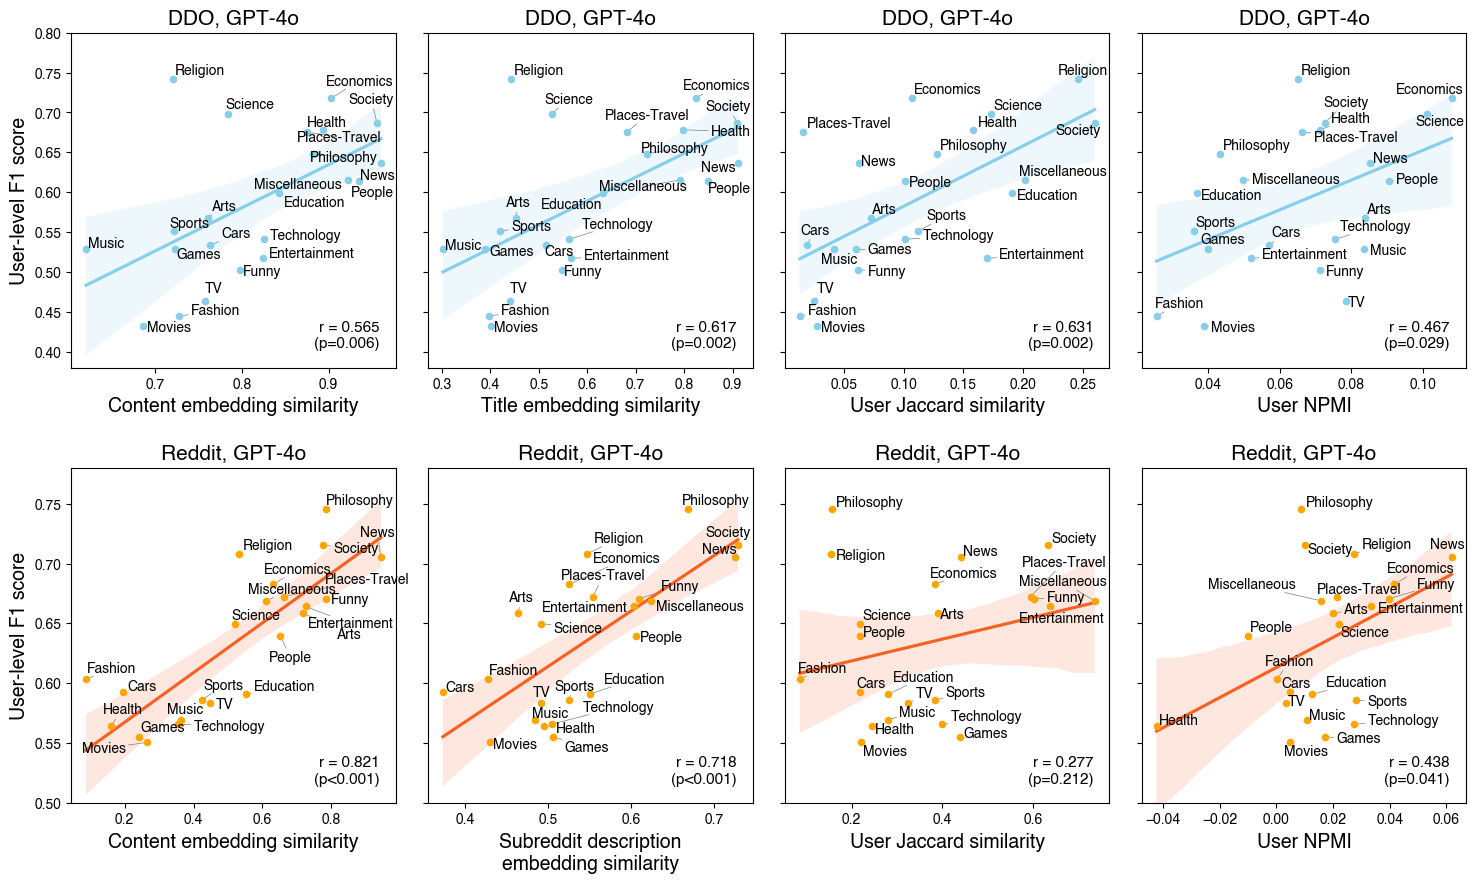

In [62]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax in axes[0, :]:
    ax.set_ylim(0.38, 0.8)
    
for ax in axes[0, 1:]:
    #ax.set_yticks([])
    ax.tick_params(axis='y', which='both', left=True, labelleft=False)
    ax.set_ylabel('')
    
plot_panel(axes[0, 0], df_content_ddo, 'content_sim', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='Content embedding similarity', ylabel='User-level F1 score')

plot_panel(axes[0, 1], df_title_ddo, 'title_sim', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='Title embedding similarity')

plot_panel(axes[0, 2], df_jaccard_ddo, 'jaccard_sim', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='User Jaccard similarity')

plot_panel(axes[0, 3], df_npmi_ddo, 'npmi', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='User NPMI')



#bottom low
for ax in axes[1, :]:
    ax.set_ylim(0.5, 0.78)

for ax in axes[1, 1:]:
    #ax.set_yticks([])
    ax.tick_params(axis='y', which='both', left=True, labelleft=False)
    ax.set_ylabel('')


plot_panel(axes[1, 0], df_content_reddit, 'content_sim', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='Content embedding similarity', ylabel='User-level F1 score',scatter_color='orange', reg_color='#F86024')

plot_panel(axes[1, 1], df_title_reddit, 'description_sim', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='Subreddit description\nembedding similarity',scatter_color='orange', reg_color='#F86024' )

plot_panel(axes[1, 2], df_jaccard_reddit, 'jaccard_sim', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='User Jaccard similarity',scatter_color='orange', reg_color='#F86024' )

plot_panel(axes[1, 3], df_npmi_reddit, 'npmi', 'f1_gpt', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='User NPMI',scatter_color='orange',  reg_color='#F86024' )


plt.subplots_adjust(wspace=0.1)
plt.subplots_adjust(hspace=0.3)

plt.show()


### Llama-3.1-8B Results

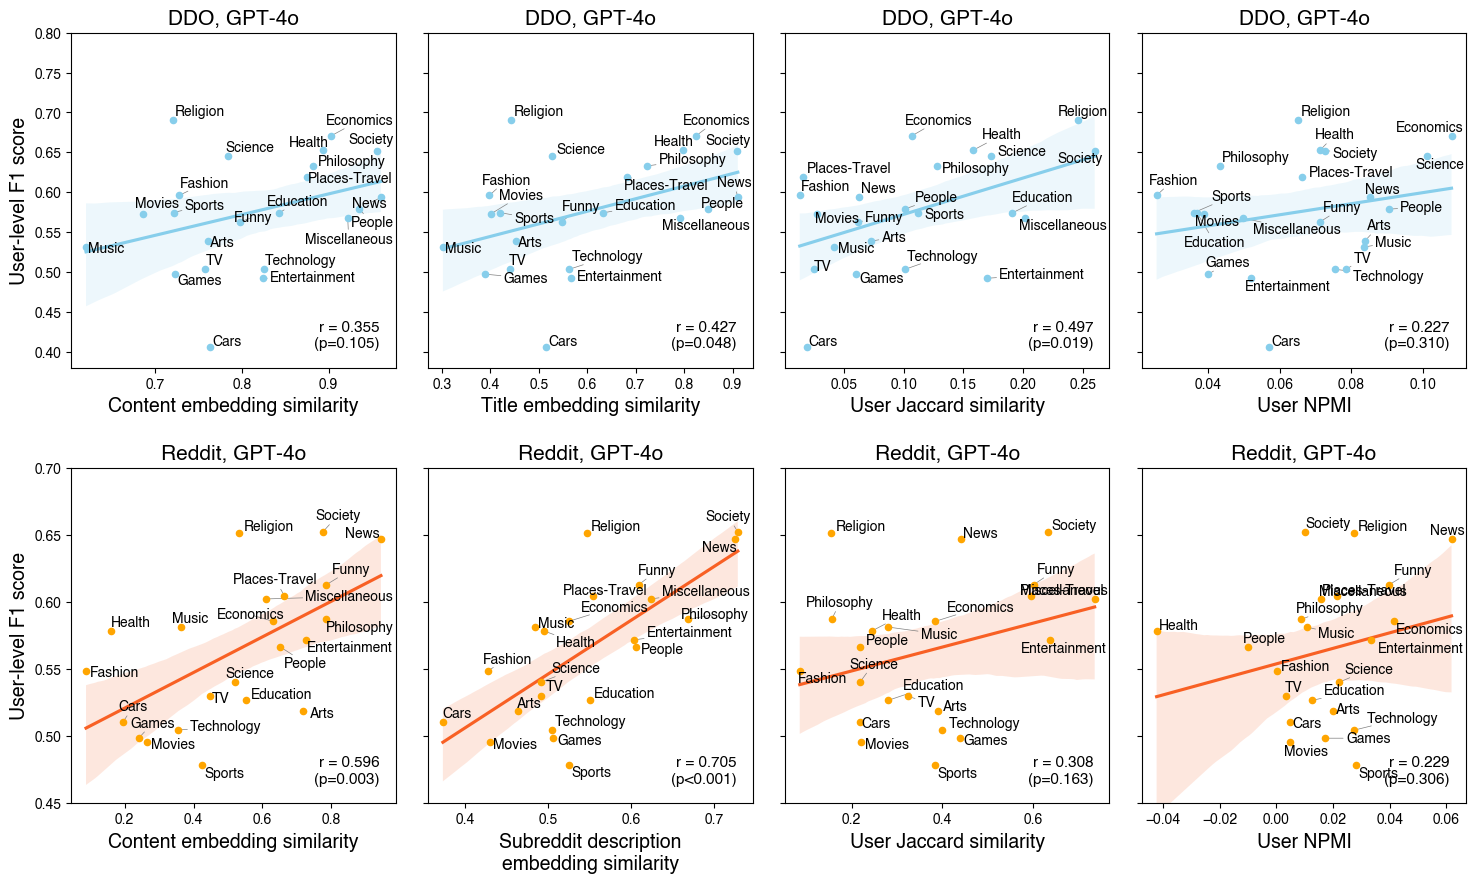

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax in axes[0, :]:
    ax.set_ylim(0.38, 0.8)
    
for ax in axes[0, 1:]:
    #ax.set_yticks([])
    ax.tick_params(axis='y', which='both', left=True, labelleft=False)
    ax.set_ylabel('')
    
plot_panel(axes[0, 0], df_content_ddo, 'content_sim', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='Content embedding similarity', ylabel='User-level F1 score')

plot_panel(axes[0, 1], df_title_ddo, 'title_sim', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='Title embedding similarity')

plot_panel(axes[0, 2], df_jaccard_ddo, 'jaccard_sim', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='User Jaccard similarity')

plot_panel(axes[0, 3], df_npmi_ddo, 'npmi', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='DDO, GPT-4o', xlabel='User NPMI')



#bottom low
for ax in axes[1, :]:
    ax.set_ylim(0.45, 0.7)

for ax in axes[1, 1:]:
    #ax.set_yticks([])
    ax.tick_params(axis='y', which='both', left=True, labelleft=False)
    ax.set_ylabel('')


plot_panel(axes[1, 0], df_content_reddit, 'content_sim', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='Content embedding similarity', ylabel='User-level F1 score',scatter_color='orange', reg_color='#F86024')

plot_panel(axes[1, 1], df_title_reddit, 'description_sim', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='Subreddit description\nembedding similarity',scatter_color='orange', reg_color='#F86024' )

plot_panel(axes[1, 2], df_jaccard_reddit, 'jaccard_sim', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='User Jaccard similarity',scatter_color='orange', reg_color='#F86024' )

plot_panel(axes[1, 3], df_npmi_reddit, 'npmi', 'f1_llama', hide_y=False, text_kwargs={'fontsize': 10}, 
           title='Reddit, GPT-4o', xlabel='User NPMI',scatter_color='orange',  reg_color='#F86024' )


plt.subplots_adjust(wspace=0.1)
plt.subplots_adjust(hspace=0.3)

plt.show()

### Correlation matrix of similarity meaubetween 

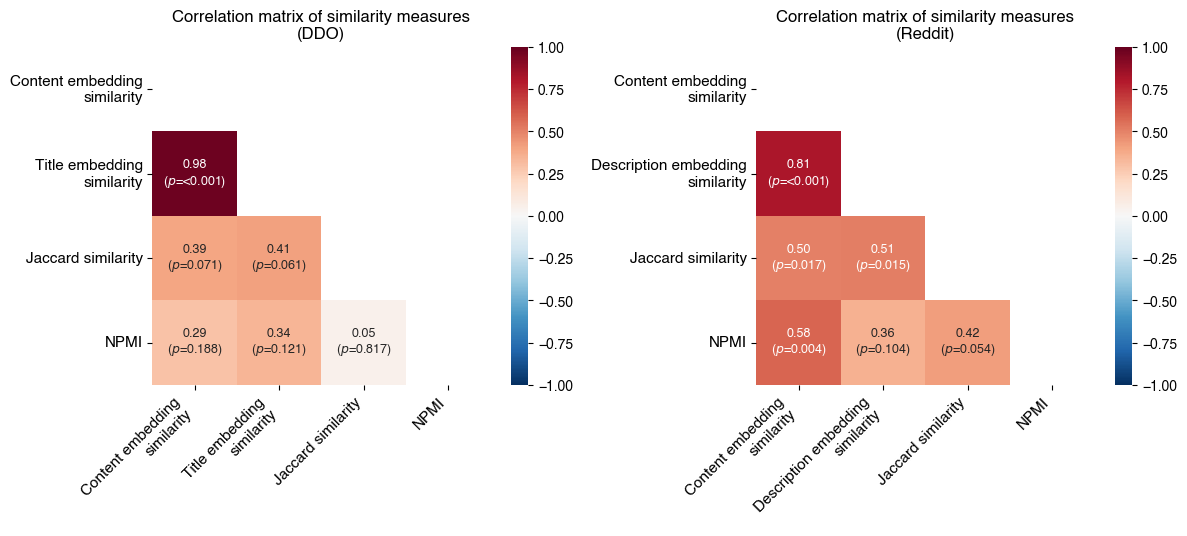

In [65]:
from scipy.stats import pearsonr

# (필요시) 라벨
labels_ddo = ['Content embedding\nsimilarity',
              'Title embedding\nsimilarity',
              'Jaccard similarity',
              'NPMI']

labels_reddit = ['Content embedding\nsimilarity',
                 'Description embedding\nsimilarity',
                 'Jaccard similarity',
                 'NPMI']

def corr_p_annot(sim_df, p_thresh=0.001):
    cols = sim_df.columns
    n = len(cols)
    corr_mat = np.zeros((n, n))
    pval_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r, p = pearsonr(sim_df[cols[i]], sim_df[cols[j]])
            corr_mat[i, j] = r
            pval_mat[i, j] = p

    annot = np.empty_like(corr_mat, dtype=object)
    for i in range(n):
        for j in range(n):
            p_text = "<0.001" if pval_mat[i, j] < p_thresh else f"{pval_mat[i, j]:.3f}"
            annot[i, j] = f"{corr_mat[i, j]:.2f}\n($p$={p_text})"
    return corr_mat, annot

# --- DDO ---
df_ddo = (
    df_content_ddo[['category', 'content_sim']]
    .merge(df_title_ddo[['category', 'title_sim']], on='category')
    .merge(df_jaccard_ddo[['category', 'jaccard_sim']], on='category')
    .merge(df_npmi_ddo[['category', 'npmi']], on='category')
)
sim_ddo = df_ddo[['content_sim', 'title_sim', 'jaccard_sim', 'npmi']]
corr_ddo, annot_ddo = corr_p_annot(sim_ddo)

# --- Reddit ---
df_reddit = (
    df_content_reddit[['category', 'content_sim']]
    .merge(df_title_reddit[['category', 'description_sim']], on='category')
    .merge(df_jaccard_reddit[['category', 'jaccard_sim']], on='category')
    .merge(df_npmi_reddit[['category', 'npmi']], on='category')
)
sim_reddit = df_reddit[['content_sim', 'description_sim', 'jaccard_sim', 'npmi']]
corr_reddit, annot_reddit = corr_p_annot(sim_reddit)

# 상삼각 가리기 (lower triangle만 표시)
mask_ddo = np.triu(np.ones_like(corr_ddo, dtype=bool))
mask_reddit = np.triu(np.ones_like(corr_reddit, dtype=bool))

# 시각화 (1x2 서브플롯, 동일 비율)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = 'RdBu_r'
labelsize = 11
titlesize = 12

# DDO
sns.heatmap(
    corr_ddo, annot=annot_ddo, fmt='', cmap=cmap, vmin=-1, vmax=1, square=True,
    ax=axes[0], xticklabels=labels_ddo, yticklabels=labels_ddo, mask=mask_ddo, annot_kws={"size": 9}
)
axes[0].set_xticklabels(labels_ddo, rotation=45, ha='right', fontsize=labelsize)
axes[0].set_yticklabels(labels_ddo, rotation=0, fontsize=labelsize)
axes[0].set_title("Correlation matrix of similarity measures\n(DDO)")

# Reddit
sns.heatmap(
    corr_reddit, annot=annot_reddit, fmt='', cmap=cmap, vmin=-1, vmax=1, square=True,
    ax=axes[1], xticklabels=labels_reddit, yticklabels=labels_reddit, mask=mask_reddit, annot_kws={"size": 9}
)
axes[1].set_xticklabels(labels_reddit, rotation=45, ha='right', fontsize=labelsize)
axes[1].set_yticklabels(labels_reddit, rotation=0, fontsize=labelsize)
axes[1].set_title("Correlation matrix of similarity measures\n(Reddit)")

for ax in axes:
    ax.collections[0].colorbar.ax.tick_params(labelsize=10)

plt.tight_layout()
#plt.savefig('../fig/figs_for_paper/Fig3_source/similarity_correlation_matrix.pdf',transparent=True, bbox_inches='tight')
plt.show()
